# Stochastic Series Expansion for the Spin-1/2 Heisenberg Chain

- **Autor:** Théo HUET
- **Degree** Master 2 of Physics Thoeric
- **Institution** University of CY Cergy-Paris Université
- **Course** Quantum Monte Carlo, Andreas Honecker
- **Date** March, 2026

## 1. Introduction

### 1.1 Context and Motivation
The Stochastic Series Expansion (SSE) is a highly efficient Quantum Monte Carlo (QMC) method designed to study the thermodynamic properties of quantum lattice models at finite temperatures. Unlike methods based on the Suzuki-Trotter decomposition, SSE avoids systematic time-discretization errors by directly sampling the Taylor expansion of the partition function. This approach is essential for investigating many-body quantum systems where the Hilbert space grows exponentially, making exact diagonalization computationally impossible for large system sizes. By mapping the quantum problem onto a high-dimensional classical configuration space of operator sequences, SSE provides a powerful tool for obtaining high-precision results for magnetic and thermal observables.

In [589]:
import numpy as np
import matplotlib.pyplot as plt

### 1.2 Theoretical Background
The core of this project is the study of the one-dimensional spin-1/2 Heisenberg model. The system is described by the following Hamiltonian:

$$H = J \sum_{i=1}^{L} \vec{S}_{i} \cdot \vec{S}_{i+1}$$

- where $L$ is the length of the chain and periodic boundary conditions are assumed, such that $L+1 \equiv 1$. Understanding this project requires familiarity with:
- **The Heisenberg Model:** A fundamental paradigm for describing exchange interactions between neighboring spins in magnetic materials.
- **Exchange Coupling ($J$):** The behavior of the system changes drastically depending on the sign of $J$, leading to either an Anti-ferromagnetic ($J=1$) or a Ferromagnetic ($J=-1$) ground state.
- **Magnetic Susceptibility ($\chi$):** A thermodynamic response function that characterizes how the magnetization of the system reacts to an external magnetic field, which we will compute as a function of temperature $T$.
- **Statistical Mechanics of SSE:** The representation of the partition function $Z = \text{Tr}(e^{-\beta H})$ as a summation over operator strings and spin states, with $\beta = \frac{1}{T k_B}$.

In [ ]:
global L
L = 50

### 1.3 Objectives of the Project
The primary goal is to develop a robust numerical tool to simulate the magnetic properties of a 1D quantum spin chain. The specific objectives are:

1. **Algorithm Implementation:** Develop and implement the SSE algorithm tailored for the spin-1/2 Heisenberg chain.
2. **Thermodynamic Analysis:** Compute and plot the magnetic susceptibility $\chi(T)$ for both the anti-ferromagnetic ($J=1$) and ferromagnetic ($J=-1$) cases.
3. **Statistical Validation:** Implement rigorous thermalization protocols and estimate error bars by performing independent repetitions of the calculations to ensure the reliability of the results.

In [591]:
def init_spin_chain() -> np.ndarray: # random spin chain
  S = 1 #we take 1 for efficency
  return np.random.choice([-S, S], size=L)

---

## 2. Theoretical Framework

### 2.1 The SSE Partition Function

The starting point for any thermodynamic study in the canonical ensemble is the partition function $Z$ at an inverse temperature $\beta = 1/k_B T$. For a quantum system governed by a Hamiltonian $H$, the partition function is defined as the trace of the density matrix:

$$Z = \text{Tr}(e^{-\beta H}) = \sum_{\alpha} \langle \alpha | e^{-\beta H} | \alpha \rangle$$

where $\{|\alpha\rangle\}$ is an orthonormal basis of the Hilbert space (typically the computational basis in the $S^z$ representation for spin systems). By expanding the exponential operator into its power series $e^{-\beta H}= \sum_{n=0}^{\infty} \frac{\beta^n}{n!}(-H)^n$, we obtain:

$$Z = \sum_{\alpha} \sum_{n=0}^{\infty} \frac{\beta^n}{n!} \langle \alpha | (-H)^n | \alpha \rangle$$

This formulation transforms the problem into a summation over all possible states $|\alpha\rangle$ and all possible expansion orders $n$. In a numerical simulation, the infinite sum is truncated at a sufficiently large cut-off $M$, such that the contribution of terms with $n > M$ is negligible.

### 2.2 The Configuration Space

In the SSE framework, the "configurations" sampled by the Monte Carlo algorithm are not just physical states, but pairs $(|\alpha\rangle, S_n)$, where:
* $|\alpha\rangle$ is an initial state of the basis.
* $S_n$ is an **operator string** consisting of a sequence of $n$ local components of the Hamiltonian $H$.

The weight of a specific configuration is determined by the matrix element $\langle \alpha | H^n | \alpha \rangle$. For this weight to be easily computable and non-negative (to avoid the infamous "sign problem"), we must decompose the global Hamiltonian $H$ into a sum of elementary, local bond operators.

This leads us to the necessity of rewriting our Heisenberg Hamiltonian in a form that distinguishes between diagonal and non-diagonal contributions.

### 2.3 Hamiltonian Decomposition and Sublattice Transformation
To implement the SSE, we decompose the Hamiltonian $H$ into a sum of local bond operators $H_{a,b}$, where $b$ denotes a bond $(i, i+1)$ and $a \in \{1, 2\}$ indicates the type of operator (diagonal or off-diagonal). We aim for a form:
$$-H = \sum_{b=1}^{L} (H_{1,b} + H_{2,b}) + \text{const}$$

Using the identity $\vec{S}_{i} \cdot \vec{S}_{j} = S_i^zS_j^z + \frac{1}{2} (S_i^+ S_j^- + S_i^- S_j^+)$, the Heisenberg Hamiltonian is:
$$H = J \sum_{i=1}^{L} \left[ S_i^z S_{i+1}^z + \frac{1}{2}(S_i^+ S_{i+1}^- + S_i^- S_{i+1}^+) \right]$$

For the **Ferromagnet** ($J=-1$), the terms in $-H$ are naturally positive. However, for the **Antiferromagnet** ($J=1$), the off-diagonal terms in $-H$ would be negative, leading to a sign problem. Since the 1D chain is a bipartite lattice, we apply a unitary transformation (a $\pi$-rotation around the $z$-axis) on one sublattice: $S_j^\pm \to -S_j^\pm$ and $S_j^z \to S_j^z$. This yields the following bond operators for both cases:

* **Diagonal Operator ($a=1$):** $H_{1,b} = \frac{1}{4} - S_i^z S_{i+1}^z$
* **Off-diagonal Operator ($a=2$):** $H_{2,b} = \frac{1}{2}(S_i^+ S_{i+1}^- + S_i^- S_{i+1}^+)$

This leads to the convenient form:
$$-H = \sum_{b=1}^L (H_{1,b} + H_{2,b}) - \frac{L}{4}$$

### 2.4 Positivity of Operator Weights
A crucial requirement for Monte Carlo sampling is that all configuration weights must be non-negative. Let's examine the action of our operators on the local basis $\{|\uparrow\uparrow\rangle, |\uparrow\downarrow\rangle, |\downarrow\uparrow\rangle, |\downarrow\downarrow\rangle\}$:

**For the Diagonal Operator $H_{1,b}$:**
* $H_{1,b} |\uparrow\uparrow\rangle = (\frac{1}{4} - \frac{1}{4}) |\uparrow\uparrow\rangle = 0$
* $H_{1,b} |\downarrow\downarrow\rangle = (\frac{1}{4} - \frac{1}{4}) |\downarrow\downarrow\rangle = 0$
* $H_{1,b} |\uparrow\downarrow\rangle = (\frac{1}{4} - (-\frac{1}{4})) |\uparrow\downarrow\rangle = \frac{1}{2} |\uparrow\downarrow\rangle$
* $H_{1,b} |\downarrow\uparrow\rangle = (\frac{1}{4} - (-\frac{1}{4})) |\downarrow\uparrow\rangle = \frac{1}{2} |\downarrow\uparrow\rangle$

**For the Off-diagonal Operator $H_{2,b}$:**
* $H_{2,b} |\uparrow\uparrow\rangle = 0$
* $H_{2,b} |\downarrow\downarrow\rangle = 0$
* $H_{2,b} |\uparrow\downarrow\rangle = \frac{1}{2} |\downarrow\uparrow\rangle$
* $H_{2,b} |\downarrow\uparrow\rangle = \frac{1}{2} |\uparrow\downarrow\rangle$

In all cases, the non-zero matrix elements are $\langle \alpha' | H_{a,b} | \alpha \rangle = 1/2$. The weights are strictly non-negative, ensuring a sign-problem-free simulation.

### 2.5 Fixed-Length Operator String Representation
To handle the summation over $n$ efficiently, we introduce a fixed-length expansion. We truncate the series at a maximum cutoff $M$ and fill the remaining $M-n$ slots with the identity operator $H_{0,0} \equiv I$. The number of ways to arrange $n$ operators in $M$ slots is given by the binomial coefficient $\binom{M}{n}$.

The partition function $Z$ is rewritten as:
$$Z = \sum_{\alpha} \sum_{S_M} \frac{\beta^n (M-n)!}{M!} \langle \alpha | \prod_{i=1}^{M} H_{a_i,b_i} | \alpha \rangle$$

where $S_M$ is the operator string of length $M$ containing $n$ active operators ($a>0$) and $M-n$ identities ($a=0$). The weight of a specific configuration $(\alpha, S_M)$ is thus:
$$W(\alpha, S_M) = \beta^n \frac{(M-n)!}{M!} \left( \frac{1}{2} \right)^n$$

This weight will be used in the Metropolis-Hastings updates to sample the configuration space.

---

## 3. Numerical Implementation

Moving from the theoretical expansion to a computational algorithm requires an efficient way to store and manipulate the sequence of operators.

### 3.1 Operator String Representation

The operator string $S_M$ is the central object of the SSE algorithm. We represent it using a one-dimensional NumPy array of fixed length $M$, where $M$ is the truncation cutoff of the Taylor expansion.

Initially, the string is populated with identity operators. To distinguish between the different types of operators (Identity, Diagonal, and Off-diagonal) and the specific bonds they act upon, we use an integer encoding scheme. Given a bond index $b \in \{0, 1, \dots, L-1\}$, the encoding is defined as follows:

* **Identity Operator ($H_{0,0}$):** Represented by `-1`.
* **Diagonal Operator ($H_{1,b}$):** Represented by an even integer `2b`.
* **Off-diagonal Operator ($H_{2,b}$):** Represented by an odd integer `2b + 1`.

In this convention, the bond index $b$ can be retrieved easily via integer division.

Each integer in the `op_string` (if not -1) points to a specific bond $b$ connecting two sites $(i, j)$ in the 1D chain. With periodic boundary conditions, site $i$ is connected to $j = (i+1) \pmod L$.

This representation is highly efficient for the Monte Carlo updates, as checking whether an operator is diagonal or off-diagonal simply requires checking the parity of the integer, and the identity operator is handled as a special case.


In [592]:
def init_op_strings(M:int) -> np.ndarray :
  return -np.ones(M, dtype=int)  # all are -1 : identity

def compute_bond(op_string_p:float) :
  assert op_string_p != -1 # identity
  bond = op_string_p // 2
  return bond, (bond + 1) % L

---

### 3.2 Diagonal Update

The diagonal update is the primary mechanism for changing the expansion order $n$ in the Stochastic Series Expansion. In this step, we explore different operator string lengths by attempting to insert or remove diagonal operators.

In this procedure, we iterate through all $M$ slots of the operator string. At each step, the action depends on the type of operator currently occupying the slot:

* **Identity Operator ($a=0$):** We propose replacing it with a diagonal operator. We randomly pick a bond $b$ from the $L$ possibilities. The condition for a successful insertion depends on the nature of the physical coupling $J$:
    * **Antiferromagnetic case ($J > 0$):** The diagonal operator yields a non-zero matrix element only for **antiparallel** spins ($S^z_i \neq S^z_j$).
    * **Ferromagnetic case ($J < 0$):** The operator requires **parallel** spins ($S^z_i = S^z_j$).
    
    If the spin configuration at the bond $b$ satisfies the condition, we accept the insertion with a Metropolis probability:
    $$P_{\text{insert}} = \min \left( 1, \frac{\beta |J| L}{2(M-n)} \right)$$
    The factor of $1/2$ arises from the matrix element of the local bond operator acting on a valid spin pair, while the factor $L$ accounts for the selection probability of choosing one specific bond out of the $L$ available in the system.

* **Diagonal Operator ($a=1$):** We propose replacing it with an identity operator. The removal is accepted with the corresponding reverse Metropolis probability:
    $$P_{\text{remove}} = \min \left( 1, \frac{2(M-n+1)}{\beta |J| L} \right)$$

* **Off-Diagonal Operator ($a=2$):** During the diagonal update, off-diagonal operators are left untouched as they represent "kinks" in the imaginary time evolution. However, we must flip the values of the two spins involved in the off-diagonal operator ($S_i \to -S_i, S_j \to -S_j$) to correctly propagate the state $|\alpha\rangle$ for the subsequent slots, ensuring that the state at the end of the string (at $\tau = \beta$) matches the initial state (at $\tau = 0$).

We only insert and remove diagonal operators because they act on the local state without altering the spin configuration, making them ideal for simple Metropolis steps. Off-diagonal operators, which change the spin values, are much more efficiently updated using non-local cluster updates—such as **loop updates**—that flip entire connected pathways of spins and operators simultaneously to ensure ergodicity.

In [593]:
def insertion(op_string:np.ndarray, M:int, n:int, p:int, bond:int, beta:float, J:float) ->int:
    if n == M : #impossible de faire l'insertion
        return n
    else :
        prob = (beta * np.abs(J)*L) / (2. * (M - n))
    if np.random.rand() <  min(1., prob):
        op_string[p] = 2 * bond
        n += 1
    return n

def remove(op_string:np.ndarray, M:int, n:int, p:int, beta:float, J:float) ->int:
    prob = (2. *(M - n + 1)) / (beta * np.abs(J) * L)
    if np.random.rand() <  min(1., prob):
        op_string[p] = -1
        n -= 1
    return n

def can_insert(spins_i:int, spins_j:int, J:float)->bool :
    if J > 0: # Antiferro
        return spins_i != spins_j
    # Ferro
    return spins_i == spins_j

def diagonal_update(spins:np.ndarray, op_string:np.ndarray, M:int, n:int, beta:float, J:float) -> int:
    spins_p = spins.copy()
    for p in range(M):
        op = op_string[p]
        if op == -1 : # identity
            bond = np.random.randint(0, L)
            i = bond
            j = (bond + 1) % L
            
            if can_insert(spins_p[i], spins_p[j], J): # insertion possible?
                n = insertion(op_string, M, n, p, bond, beta, J)

        elif op % 2 == 0 : # diagonal
            i, j = compute_bond(op)
            assert can_insert(spins_p[i], spins_p[j], J), f"BUG FATAL: Opérateur diagonal sur des spins parallèles (site {i}-{j}) à p={p} !"
            n = remove(op_string, M, n, p, beta, J)
        else : # off-diagonal
            i, j = compute_bond(op)
            spins_p[i] *= -1
            spins_p[j] *= -1
    assert np.array_equal(spins, spins_p), "BUG FATAL: L'état final (tau=beta) ne correspond pas à l'état initial (tau=0) !"
    return n

---

### 3.3 Linked Vertex List Construction

To perform non-local updates (the "Loop Updates"), the algorithm needs to navigate through the configuration space efficiently. While the operator string is stored as a linear sequence, the physical connectivity of the spins creates a complex graph. The **Linked Vertex List** is the data structure that maps this connectivity.

#### The Vertex Model
Each operator $H_{a,b}$ in the string at a position $p$ can be viewed as a **vertex** with four "legs" or ports, representing the state of the two spins involved before and after the operator acts:
* **Legs $4p$ and $4p+1$:** The input states (bottom legs) for sites $i$ and $j$ of bond $b$.
* **Legs $4p+2$ and $4p+3$:** The output states (top legs) for the same sites $i$ and $j$.

The total size of the link list is therefore $4M$, where $M$ is the truncation cutoff. This list stores the "address" of the next (or previous) leg connected to any given leg.

#### Spatial and Temporal Connectivity
The construction of the link list follows two types of connections:

1.  **Internal Vertex Connections:** Within a single vertex at position $p$, the connectivity depends on the operator type. For a diagonal operator, the state of a site is preserved, creating a logical link between its input and output legs. For an off-diagonal operator, the spins are swapped, which is reflected by cross-linking the input of one site to the output of the other. These internal links define how a "loop" will pass through an operator.
2.  **External Temporal Connections:** This is the core of the construction. For each physical site $x \in \{0, \dots, L-1\}$, we must link the output leg of an operator acting on $x$ at a certain "time" (position $p$) to the input leg of the *next* operator acting on that same site later in the sequence.

#### Handling the Trace and Periodicity
The partition function $Z = \text{Tr}(e^{-\beta H})$ implies a trace over the Hilbert space, which imposes a periodic boundary condition in the "imaginary time" direction. Numerically, this means that for each site:
* The very first operator acting on site $x$ must be linked to the very last operator acting on site $x$.
* If a site $x$ is not acted upon by any operator in the current string (only identities), it is effectively a straight line and is handled separately or ignored by the vertex-based loop.

To build this list in a single pass $O(M)$, we track the "last seen" leg for each site. When a new operator is encountered, we link its input legs to the stored "last legs" of the corresponding sites and then update the storage with the current output legs.

Once the `links` array is fully populated, every leg in the sequence (excluding those belonging to identity operators) is connected to exactly one other leg. This transforms the operator string into a set of closed, disjoint loops, which is the necessary prerequisite for the **Loop Update**.

In [ ]:
def compute_link_list(op_string:np.ndarray, M:int):
    links = np.full(4*M, -1)
    last_leg = np.full(L, -1)
    first_leg = np.full(L, -1)

    for p in range(M):
        op = op_string[p]
        if op == -1: continue # Identité = pas de vertex
        
        # on identifie les sites impliqués
        bond = op // 2
        i = bond
        j = (bond + 1) % L
        
        # "pattes" de ce vertex
        legs = [4*p + 0, 4*p + 1, 4*p + 2, 4*p + 3]
        sites = [i, j, i, j] # 0 et 2 sont sur site i, 1 et 3 sur site j

        for k in range(2): # on connecte les entrées (0 et 1)
            s = sites[k]
            leg_in = legs[k]
            if last_leg[s] == -1:
                first_leg[s] = leg_in
            else:
                prev_leg_out = last_leg[s]
                links[leg_in] = prev_leg_out
                links[prev_leg_out] = leg_in
            
            # on met a jour la dernière patte de sortie pour ce site
            last_leg[s] = legs[k+2] # 2 ou 3

    # fermeture periodique (pour la Trace)
    for s in range(L):
        if first_leg[s] != -1:
            links[first_leg[s]] = last_leg[s]
            links[last_leg[s]] = first_leg[s]
            
    return links, first_leg

---

### 3.4 Off-Diagonal (Loop) Update

While the diagonal update modifies the expansion order $n$, it is restricted to the diagonal sector and cannot change the spin configuration $|\alpha\rangle$ or the number of off-diagonal operators. To ensure ergodicity and explore the full Hilbert space, we implement the **Loop Update**. This is a cluster-type update that identifies closed paths of interconnected legs across vertices and flips them simultaneously.

#### The Concept of Directed Loops
In the SSE representation, each operator (vertex) in the string is viewed as having four legs: two lower legs (input at time $\tau$) and two upper legs (output at time $\tau+1$). Because of the conservation laws in the Heisenberg model (the "ice-rule"), every vertex has an even number of spins entering and exiting. This structure allows the entire configuration of operators and spins to be decomposed into a set of disjoint, closed loops.

#### Loop Routing and the Sign of $J$
The internal traversal of a loop within a vertex—meaning which leg the loop exits through after entering—is determined by the nature of the physical coupling $J$. This is a critical step to ensure that the "flipped" vertex remains a valid operator with a non-zero matrix element:

* **Antiferromagnetic Case ($J > 0$):** To maintain the alternating spin preference, the loop performs a **horizontal traversal** (or "bounce"). If a loop enters through leg $0$, it exits through leg $1$ (and vice versa for $2 \leftrightarrow 3$). In bitwise logic, this corresponds to `exit_leg = current_leg ^ 1`.
* **Ferromagnetic Case ($J < 0$):** To favor parallel alignment, the loop must perform a **diagonal traversal**. If a loop enters through leg $0$, it exits through the diagonally opposite leg $3$ (and $1 \leftrightarrow 2$). This corresponds to `exit_leg = current_leg ^ 3`.

#### Global Update Mechanism
The algorithm identifies all unique loops using the `links` list. For each identified loop, a stochastic decision is made to determine if the loop will be "flipped" (typically with a probability **$P = 0.5$**). This randomness is essential for the algorithm to satisfy detailed balance and correctly sample the equilibrium distribution.

If the decision is made to flip the loop:
1.  **Operator Transformation:** As the loop passes through a vertex at position $p$, the operator type is toggled. A diagonal operator ($2b$) becomes an off-diagonal operator ($2b+1$), and vice versa. This is efficiently implemented using a XOR operation: `op_string[p] ^= 1`.
2.  **Boundary Spin Update:** When a loop segment crosses the temporal boundary (from $\tau = \beta$ back to $\tau = 0$), the corresponding physical spin in the array `spins[s]` must be inverted ($S^z \to -S^z$). This ensures that the state $|\alpha\rangle$ remains consistent with the operator string's action.

#### Implementation and Efficiency
By iterating through the `links` and using a `visited` array, we ensure that every leg in the $4M$ space is processed exactly once. Additionally, sites that do not have any operators acting on them during a specific Monte Carlo step are flipped with a 50% probability to maintain ergodicity.

This non-local update is the primary reason for the SSE method's efficiency. By flipping entire clusters of spins and operators at once, the algorithm can change the total magnetization and move between distant sectors of the Hilbert space, effectively bypassing the critical slowing down that plagues local update methods at low temperatures.

In [ ]:
def leg_to_site(leg:int, op_string:np.ndarray) -> int:
  p = leg // 4
  leg_type = leg % 4
  b = op_string[p] // 2

  i = b
  j = (b+1) % L

  if leg_type in [0, 2]:
      return i
  else:
      return j

def loop_update(spins:np.ndarray, op_string:np.ndarray, links:np.ndarray, first_leg: np.ndarray, M:int, J:float):
    visited = np.zeros(4*M, dtype=bool)
    
    leg_to_site_at_boundary = {leg: s for s, leg in enumerate(first_leg) if leg != -1}

    for i in range(4*M):
        if links[i] == -1 or visited[i]: # ignore les identités et les déja visitées
            continue

        flip_loop = (np.random.rand() < 0.5)
            
        current = i
        while not visited[current]:
            visited[current] = True
            p = current // 4
            
            if flip_loop:
                op_string[p] ^= 1 

            if J > 0: # antiferro : 0<->1, 2<->3
                exit_leg = current ^ 1
            else: # ferro 0<->3, 1<->2
                exit_leg = current ^ 3
                
            visited[exit_leg] = True

            if flip_loop: # met a jour les spins
                if current in leg_to_site_at_boundary:
                    s_idx = leg_to_site_at_boundary[current]
                    spins[s_idx] *= -1
                if exit_leg in leg_to_site_at_boundary:
                    s_idx = leg_to_site_at_boundary[exit_leg]
                    spins[s_idx] *= -1

            current = links[exit_leg]

    for s in range(L):
        if first_leg[s] == -1:
            if np.random.rand() < 0.5:
                spins[s] *= -1

---

## 4. Measurements and Observables

Once the system has reached thermal equilibrium (thermalization), we can begin to sample physical observables. In the SSE framework, these observables are expressed as averages over the sampled expansion order $n$ and the spin configurations $|\alpha\rangle$.

To simplify the calculations, we set $k_B = 1$.

### 4.1 Computation furmula

#### Internal Energy

- $e = \frac 1 L(-\frac{\langle n\rangle}{\beta} + \frac{J L}4 )$

With $\frac{J L}4$ as the shift constant due to the presence of the constant in the Hamiltonian.

#### Magnetization

- $m = \frac{\langle\sum_{i=1}^L s_i\rangle}L$

We previously assumed spin values of $\pm 1$ for the efficiency, but as our physical system consists of particles with spin $1/2$, we must not forget to include a factor of $1/2$ when calculating the magnetisation.

#### Susceptibility

- $\chi = \beta \frac {\langle M^2 \rangle} L= \beta {\langle m^2 \rangle} L$

#### Specific heat

- $C = \frac 1 L (\langle n^2 \rangle - \langle n\rangle^2 - \langle n \rangle)$

For our project, we calculate these values per spin, which is why they are divided by L.

In [596]:
def compute_energy(n:list, beta:float, J:float)->float:
    return (-np.mean(n) / (beta*L) + (1/4)) # pas oublier la constante de décalage

def compute_magnetisation(spins:np.ndarray)->float:
    S = 0.5 # cause we take |spins| = 1
    return np.sum(spins)*S/L

def compute_susceptibility(m:list, beta:float)->float:
    return beta * (np.mean(np.array(m)**2))*L # we don't calculate - np.mean(m)**2, cause this part \approx 0

def compute_specific_heat(n:list)->float:
    return (np.mean(np.array(n)**2) - np.mean(n)**2 - np.mean(n))/L

---

### 4.2 Theoretical Limits: Antiferromagnetic Case ($J=+1$)

To validate our Quantum Monte Carlo implementation, we compare our numerical results against exact analytical limits derived from the Bethe Ansatz, Conformal Field Theory (CFT), and high-temperature expansions. For the isotropic spin-1/2 antiferromagnetic Heisenberg chain ($J=1$), the expected behaviors per site are as follows:

#### Internal Energy ($e = E/L$)
* **Low Temperature:** The system is described by a Tomonaga-Luttinger liquid. The energy follows a CFT prediction:
$$e(T) \approx E_0 + \frac{\pi v}{6} T^2$$
where the spin velocity is $v = \frac{\pi J}{2}$ and the exact ground-state energy is $E_0 = \frac{1}{4} - \ln(2) \approx -0.443147$.
* **High Temperature:** Expanding the partition function yields:
$$e(T) \approx -\frac{3J^2}{16T}$$

#### Magnetization ($m = \langle M_z \rangle / L$)
* In the absence of an external magnetic field, the $SU(2)$ symmetry remains unbroken, and the macroscopic magnetization is strictly zero at all temperatures:
$$m(T) = 0 \quad \forall T$$

#### Magnetic Susceptibility ($\chi$)
* **Low Temperature:** The susceptibility approaches a finite zero-temperature limit $\chi_0 = \frac{1}{\pi^2 J} \approx 0.10132$. Furthermore, the low-$T$ behavior is famously dominated by logarithmic corrections rather than a simple power law, taking the form:
$$\chi(T) \approx \chi_0 \left[ 1 + \frac{1}{2 \ln(T_0 / T)} \right]$$
where $T_0$ is a characteristic temperature scale.
* **High Temperature:** The spins become uncorrelated, and the system follows the standard Curie law for non-interacting spin-1/2 particles:
$$\chi(T) \approx \frac{1}{4T}$$

#### Specific Heat ($C$)
* **Low Temperature:** Deriving the low-$T$ energy yields a linear specific heat, characteristic of 1D gapless quantum systems:
$$C(T) \approx \frac{2}{3J} T$$
* **High Temperature:** Derived from the energy fluctuation expansion:
$$C(T) \approx \frac{3J^2}{16T^2}$$

In [597]:
global T_intermediate
T_intermediate = 0.5
T_low = 0.3
T_low = 2

def compute_E_theoric_antiferro(T:np.ndarray, J:float) -> np.ndarray:
  E0 = -0.443147 # a T=0
  v = np.pi*J/2
  E_theoric_low_T = E0 + np.pi * v * T**2 / 6

  E_theoric_high_T = - 3 * J**2/(16*T)

  return np.where(T < T_intermediate, E_theoric_low_T, E_theoric_high_T)

def compute_m_theoric_antiferro(T:np.ndarray) -> np.ndarray:
  return np.zeros_like(T)

def compute_susceptibility_theoric_antiferro(T:np.ndarray, J:float) -> np.ndarray:
  chi0 = 0.10132 # a T=0
  T0 = 7.7
  susceptibility_theoric_low_T = chi0 * (1 + 1/(2*np.log(T0/T)))

  susceptibility_theoric_high_T = 1/(4*T)

  return np.where(T < T_intermediate, susceptibility_theoric_low_T, susceptibility_theoric_high_T)

def compute_specific_heat_theoric_antiferro(T:np.ndarray, J:float) -> np.ndarray:
  specific_heat_theoric_low_T = T * 2/(3*J)

  specific_heat_theoric_high_T = 3*(J**2)/(16*(T**2))

  return np.where(T < T_intermediate, specific_heat_theoric_low_T, specific_heat_theoric_high_T)

---

### 4.3 Theoretical Limits: Ferromagnetic Case ($J=-1$)

The ferromagnetic Heisenberg chain ($J=-1$) presents a different physical behavior, especially at low temperatures.

#### Internal Energy ($e = E/L$)
- **Low Temperature:** Unlike the $T^2$ dependence seen in the antiferromagnet, the quadratic dispersion of magnons in 1D leads to:
$$e(T) \approx E_0 + \zeta(3/2) \sqrt{\frac{1}{4\pi |J|}} T^{3/2}$$
where $E_0 = J/4 = -0.25$ is the exact ground-state energy per site and $\zeta(3/2)\approx 2.612375$.
- **High Temperature:** The energy converges toward the same limit as the antiferromagnetic case:
$$e(T) \approx -\frac{3J^2}{16T}$$

#### Magnetization ($m = \langle M_z \rangle / L$)
- In accordance with the Mermin-Wagner theorem, spontaneous symmetry breaking is impossible in 1D at $T > 0$. Therefore, even for the ferromagnet:
$$m(T) = 0 \quad \forall T > 0$$
However, at exactly $T=0$, the system is in a fully polarized state where $|m| = 1/2$.

#### Magnetic Susceptibility ($\chi$)
- **Low Temperature:** The susceptibility diverges much more rapidly than the Curie law as $T \to 0$. Spin-wave theory and Bethe Ansatz calculations show a $T^{-2}$ divergence:
$$\chi(T) \approx \frac{1}{24} \frac{|J|}{T^2}$$
* **High Temperature:** The system follows the universal Curie law for independent spins:
$$\chi(T) \approx \frac{1}{4T}$$

#### Specific Heat ($C$)
- **Low Temperature:** The energy dependence $T^{3/2}$ results in a specific heat that follows:
$$C(T) \approx \frac{3}{2} \zeta(3/2) \sqrt{\frac{1}{4\pi |J|}} T^{1/2}$$
This $T^{1/2}$ behavior is a hallmark of ferromagnetic magnons in one dimension.
- **High Temperature:**
$$C(T) \approx \frac{3J^2}{16T^2}$$

In [598]:
def compute_E_theoric_ferro(T:np.ndarray, J:float) -> np.ndarray: #2.269
  E0 = J/4 # a T=0
  c = 2.612375
  E_theoric_low_T = E0 + c * np.sqrt(1/(4*np.pi*np.abs(J))) * T**(3/2)

  E_theoric_high_T = - 3/(16*T)

  return np.where(T < T_intermediate, E_theoric_low_T, E_theoric_high_T)

def compute_m_theoric_ferro(T:np.ndarray) -> np.ndarray:
  return np.zeros_like(T)

def compute_susceptibility_theoric_ferro(T:np.ndarray, J:float) -> np.ndarray:
  susceptibility_theoric_low_T = np.abs(J)/(24* T**2)

  susceptibility_theoric_high_T = 1/(4*T)

  return np.where(T < T_intermediate, susceptibility_theoric_low_T, susceptibility_theoric_high_T)

def compute_specific_heat_theoric_ferro(T:np.ndarray, J:float) -> np.ndarray:
  c = 2.612375
  specific_heat_theoric_low_T = 3/2 * c * np.sqrt(T/(4*np.pi*np.abs(J)))

  specific_heat_theoric_high_T = 3*J**2/(16*(T**2))

  return np.where(T < T_intermediate, specific_heat_theoric_low_T, specific_heat_theoric_high_T)

---

## 5. Simulation

### 5.0 Spin chain visualisation

In [599]:
def plot_chain(spins : np.ndarray, T : float) :
    plt.title(f"For T={round(T, 4)}")
    plt.imshow(spins.reshape(1,len(spins)), cmap="gray")
    plt.show()

---

### 5.1 Thermalization

In any Monte Carlo simulation, and specifically in the Stochastic Series Expansion (SSE), the quality of the results depends on two critical factors: ensuring the system has reached equilibrium and quantifying the statistical uncertainty of the measurements.

When a simulation begins, the initial state, a random configuration is highly unlikely to be a representative sample of the Boltzmann distribution at the target temperature $T$.

The Markov Chain requires a certain number of steps, known as the **thermalization**, to "forget" its starting configuration and converge toward the equilibrium distribution.

During this phase:

- The expansion order n grows from its initial value (often zero) to fluctuate around its equilibrium average $\langle n\rangle \approx −\beta \langle H\rangle$.
- The operator string $S_M​$ populates with a physically consistent density of diagonal and off-diagonal operators.
- The spin configuration $|\alpha\rangle$ reorganizes to reflect the correlations (antiferromagnetic or ferromagnetic) of the Hamiltonian.

Data collected during this period is biased by the initial conditions and must be discarded. In our implementation, we typically monitor the stabilization of n to determine when the system has reached a steady state before we begin recording observables.

In [600]:
def N_thermalization(Nt) -> int: # The system needs to reach thermal equilibrium before we can calculate the quantities
  return int(0.2 * Nt)

In [601]:
def check_periodicity(spins, op_string):
    s = np.copy(spins)
    for op in op_string:
        if op == -1: continue
        if op % 2 != 0: # Si Off-Diagonal
            bond = op // 2
            i, j = bond, (bond + 1) % L
            s[i] *= -1
            s[j] *= -1
    if not np.array_equal(s, spins):
        print("ERREUR GRAVE : La propagation ne boucle pas !")

In [602]:
def simulation(N_sweeps:int, beta:float, J:float) :
    n_list, magnetisation_list, M_list = [], [], [] # liste de mesure

    #initialisation
    M = int(2 * beta * L)
    spins = init_spin_chain()
    op_string = init_op_strings(M)
    n = 0
    
    for step in range(N_sweeps):
        n = diagonal_update(spins, op_string, M, n, beta, J)
        links, first_leg = compute_link_list(op_string, M)
        loop_update(spins, op_string, links, first_leg, M, J)
        check_periodicity(spins, op_string)
        
        # assert n == np.count_nonzero(op_string+1) # -> True
        
        if n > 0.9 * M: # update M because we need M > n
            new_M = int(1.5 * M)

            new_op_string = -np.ones(new_M, dtype=int)
            new_op_string[:M] = op_string

            op_string = new_op_string
            M = new_M

        if step > N_thermalization(N_sweeps):
            n_list.append(n)
            magnetisation_list.append(compute_magnetisation(spins))
            M_list.append(M)

    plot_chain(spins, 1/beta)
    return n_list, magnetisation_list, M_list

---

### 5.2 Statistical Errors and Independent Runs

A fundamental challenge in Monte Carlo methods is that successive configurations are correlated. If we measure the susceptibility $\chi$ at step $i$ and then again at step $i+1$, the values will be very similar because the Loop Update only changed a fraction of the system.

To obtain a reliable estimate of the true thermodynamic value and its associated uncertainty, we employ the following strategy:
**Multiple Independent Runs**

Following the project requirements, we repeat each simulation 10 times for every temperature point. Each run starts with a different random seed, ensuring that the trajectories in the configuration space are entirely independent. This approach effectively bypasses the problem of autocorrelation times within a single long chain.

In [603]:
def error(quantitie:list, n_runs:int) -> float: # for the error bar
  return np.std(quantitie) / np.sqrt(n_runs)

In [604]:
def simulation_n_runs(n_runs:int, Nt:int, beta:float, J:float) :
    energy_list, magnetisation_list, susceptibility_list, specific_heat_list, n_list, M_list = [], [], [], [], [], []
    for run in range(n_runs) :
        print(f"- run : {run+1}/{n_runs}")
        n_temp, magnetisation_temp, M_temp = simulation(Nt, beta, J)

        energy_list.append(compute_energy(n_temp, beta, J))
        magnetisation_list.append(np.abs(np.mean(magnetisation_temp))) # abs(m) parce que invariance Z2
        susceptibility_list.append(compute_susceptibility(magnetisation_temp, beta))
        specific_heat_list.append(compute_specific_heat(n_temp))
        n_list.append(n_temp)
        M_list.append(M_temp)
    return energy_list, magnetisation_list, susceptibility_list, specific_heat_list, n_list, M_list

---

### 5.3 Multiple temperatures simulation

We will therefore simulate the 1D Heisenberg model for several temperature values to see if we can reproduce the theoretical values of this model.

In [605]:
def simulation_temperature_range(temp_list : np.ndarray, Nt:int, n_runs:int, J:float) :    
    beta_list = (1/temp_list).round(4) #kb=1

    energy_list, magnetisation_list, susceptibility_list, specific_heat_list, n_list, M_list = [], [], [], [], [], []
    e_error, m_error, s_error, c_error, n_error, M_error = [], [], [], [], [], []
    for beta in beta_list :
        print(f"----------\nbeta={beta}")
        energy_temp, magnetisation_temp, susceptibility_temp, specific_heat_temp, n_temp, M_temp = simulation_n_runs(n_runs, Nt, beta, J)

        energy_list.append(np.mean(energy_temp))
        magnetisation_list.append(np.mean(magnetisation_temp))
        susceptibility_list.append(np.mean(susceptibility_temp))
        specific_heat_list.append(np.mean(specific_heat_temp))
        n_list.append(np.mean(n_temp))
        M_list.append(np.mean(M_temp))

        e_error.append(error(energy_temp, n_runs))
        m_error.append(error(magnetisation_temp, n_runs))
        s_error.append(error(susceptibility_temp, n_runs))
        c_error.append(error(specific_heat_temp, n_runs))
        n_error.append(error(n_temp, n_runs))
        M_error.append(error(M_temp, n_runs))
    return energy_list, e_error, magnetisation_list, m_error, susceptibility_list, s_error, specific_heat_list, c_error, n_list, n_error, M_list, M_error

---

### 5.4 Plot all the result function

In [ ]:
def plot_result(temp_list, 
                energy_list, e_error, 
                magnetisation_list, m_error, 
                susceptibility_list, s_error, 
                specific_heat_list, c_error, 
                n_list, n_error, 
                M_list, M_error, 
                J:float ):
    temp_list_theoric = np.linspace(temp_list[0],temp_list[-1], 200)

    if J == 1. : #anti ferro case
        E_theoric = compute_E_theoric_antiferro(temp_list_theoric, J)
        m_theoric = compute_m_theoric_antiferro(temp_list_theoric)
        susceptibility_theoric = compute_susceptibility_theoric_antiferro(temp_list_theoric, J)
        specific_heat_theoric = compute_specific_heat_theoric_antiferro(temp_list_theoric, J)
    else: # ferro case
        E_theoric = compute_E_theoric_ferro(temp_list_theoric, J)
        m_theoric = compute_m_theoric_ferro(temp_list_theoric)
        susceptibility_theoric = compute_susceptibility_theoric_ferro(temp_list_theoric, J)
        specific_heat_theoric = compute_specific_heat_theoric_ferro(temp_list_theoric, J)

    fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(12, 18))
    axs = axs.flatten()
    
    axs[0].errorbar(temp_list, energy_list, yerr=e_error, fmt='o-', color='blue', capsize=5, label='SSE Data')
    axs[0].plot(temp_list_theoric, E_theoric, linestyle='--', color='red', label='theoric value')
    axs[0].set_title(f"Energy by site")
    axs[0].set_xlabel("Temperature")
    axs[0].set_ylabel("Energy")
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    axs[1].errorbar(temp_list, magnetisation_list, yerr=m_error, fmt='o-', color='orange', capsize=5, label='SSE Data')
    axs[1].plot(temp_list_theoric, m_theoric, linestyle='--', color='red', label='theoric value')
    axs[1].set_title(f"Magnetisation by site")
    axs[1].set_xlabel("Temperature")
    axs[1].set_ylabel("magnetisation")
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    axs[2].errorbar(temp_list, susceptibility_list, yerr=s_error, fmt='o-', color='green', capsize=5, label='SSE Data')
    axs[2].plot(temp_list_theoric, susceptibility_theoric, linestyle='--', color='red', label='theoric value')
    axs[2].set_title(f"Susceptibility by site")
    axs[2].set_xlabel("Temperature")
    axs[2].set_ylabel("susceptibility")
    axs[2].legend()
    axs[2].grid(True, alpha=0.3)

    axs[3].errorbar(temp_list, specific_heat_list, yerr=c_error, fmt='o-', color='purple', capsize=5, label='SSE Data')
    axs[3].plot(temp_list_theoric, specific_heat_theoric, linestyle='--', color='red', label='theoric value')
    axs[3].set_title(f"Specific Heat by site")
    axs[3].set_xlabel("Temperature")
    axs[3].set_ylabel("specific heat")
    axs[3].legend()
    axs[3].grid(True, alpha=0.3)

    axs[4].errorbar(temp_list, n_list, yerr=n_error, fmt='o-', color='blue', capsize=5, label='n')
    axs[4].errorbar(temp_list, M_list, yerr=M_error, fmt='x-', color='red', capsize=5, label='M')
    axs[4].set_title(f"<n> compared to M")
    axs[4].set_xlabel("Temperature")
    axs[4].set_ylabel("n")
    axs[4].legend()
    axs[4].grid(True, alpha=0.3)

    axs[5].axis('off')

    fig.suptitle(f"L={L}, J={J}", fontsize=16)
    plt.tight_layout()
    plt.show()

    if J == 1. :
        print(energy_list[0], "=? -0.443147")
    else :
        print(energy_list[0], "=? -0.25")

---

## 6. Result

### 6.0 Parameters

In [607]:
Nt = 10000
n_runs = 10

Ti = 0.01
Tf = 10
temp_list = np.linspace(Ti, Tf, 20)

### 6.1 Anti-ferromagnetic case : $J=1$

----------
beta=100.0
- run : 1/10


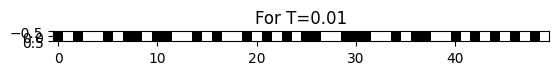

- run : 2/10


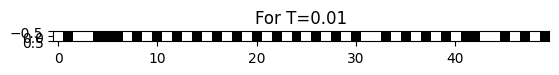

- run : 3/10


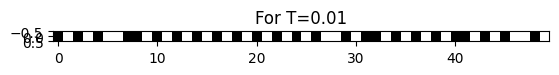

- run : 4/10


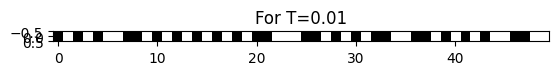

- run : 5/10


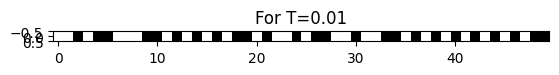

- run : 6/10


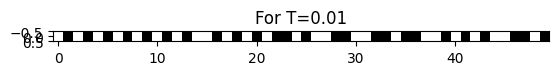

- run : 7/10


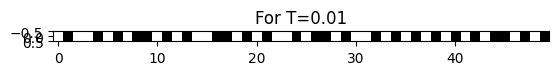

- run : 8/10


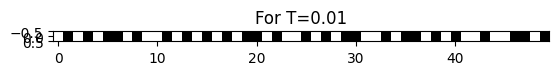

- run : 9/10


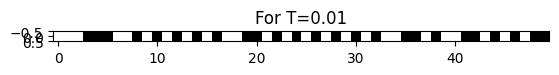

- run : 10/10


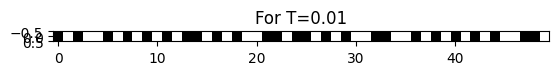

----------
beta=1.8664
- run : 1/10


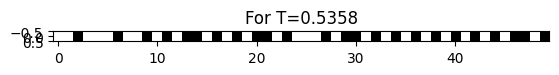

- run : 2/10


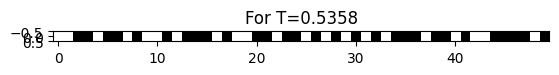

- run : 3/10


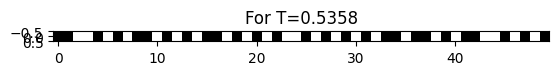

- run : 4/10


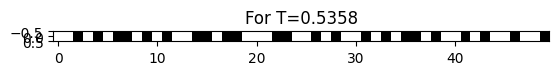

- run : 5/10


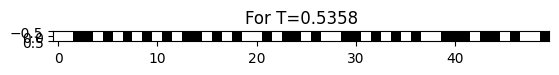

- run : 6/10


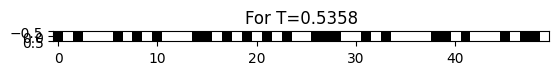

- run : 7/10


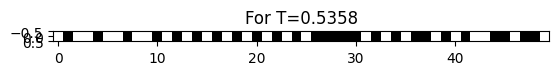

- run : 8/10


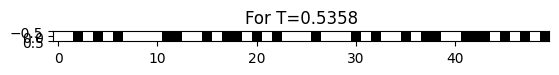

- run : 9/10


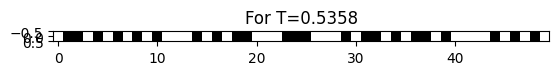

- run : 10/10


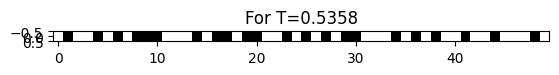

----------
beta=0.942
- run : 1/10


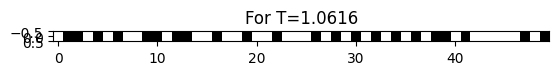

- run : 2/10


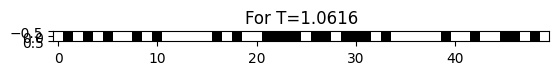

- run : 3/10


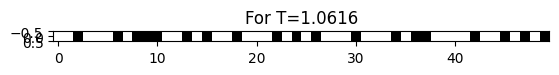

- run : 4/10


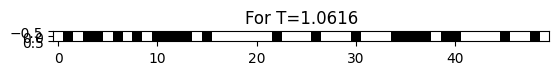

- run : 5/10


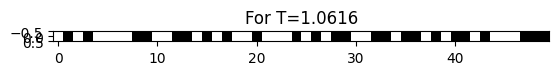

- run : 6/10


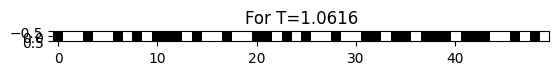

- run : 7/10


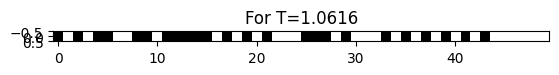

- run : 8/10


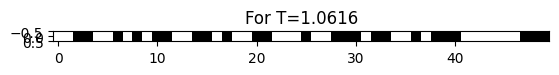

- run : 9/10


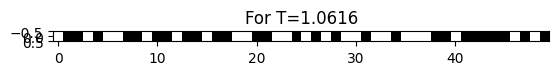

- run : 10/10


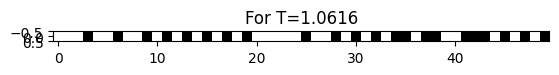

----------
beta=0.63
- run : 1/10


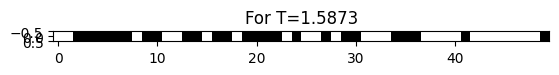

- run : 2/10


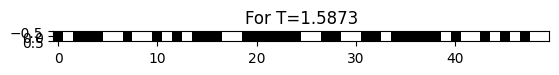

- run : 3/10


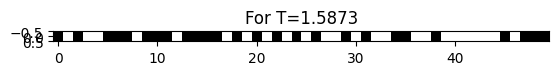

- run : 4/10


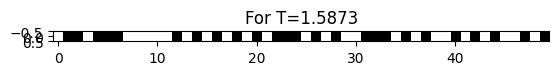

- run : 5/10


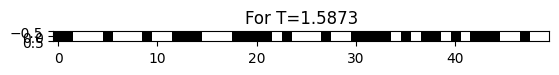

- run : 6/10


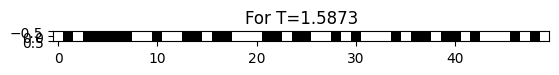

- run : 7/10


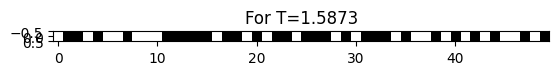

- run : 8/10


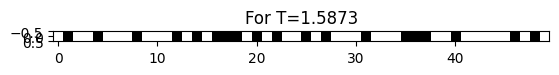

- run : 9/10


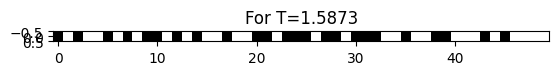

- run : 10/10


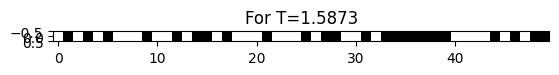

----------
beta=0.4732
- run : 1/10


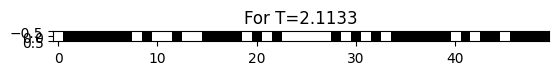

- run : 2/10


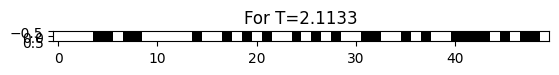

- run : 3/10


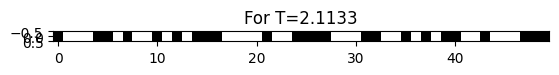

- run : 4/10


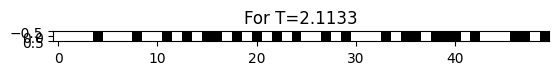

- run : 5/10


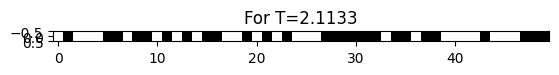

- run : 6/10


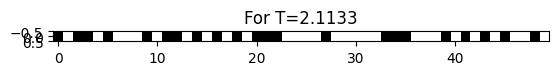

- run : 7/10


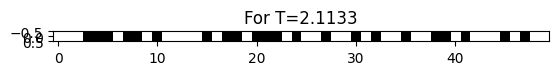

- run : 8/10


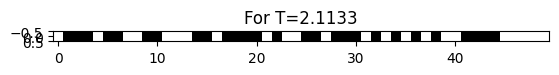

- run : 9/10


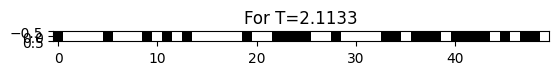

- run : 10/10


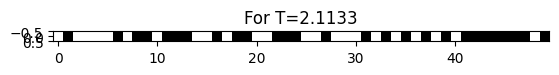

----------
beta=0.3789
- run : 1/10


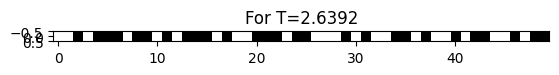

- run : 2/10


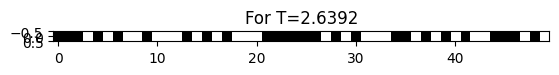

- run : 3/10


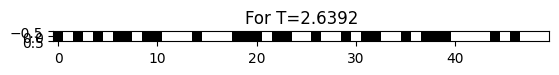

- run : 4/10


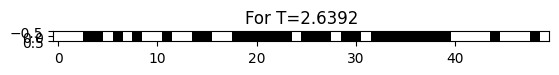

- run : 5/10


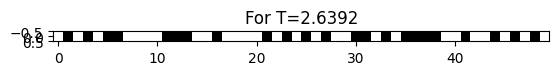

- run : 6/10


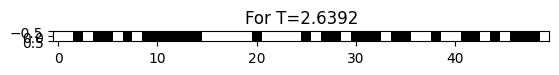

- run : 7/10


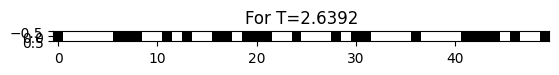

- run : 8/10


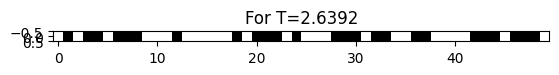

- run : 9/10


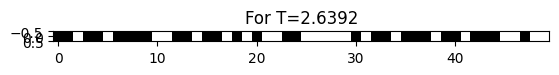

- run : 10/10


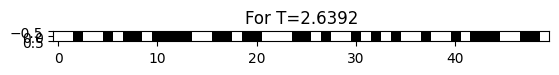

----------
beta=0.316
- run : 1/10


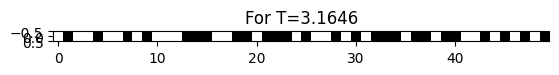

- run : 2/10


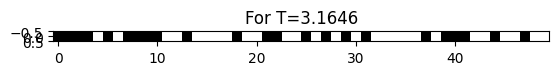

- run : 3/10


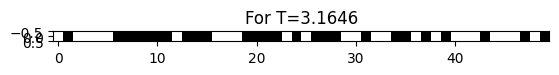

- run : 4/10


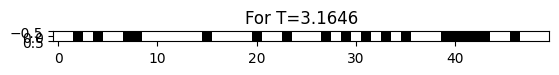

- run : 5/10


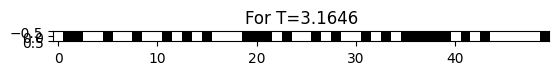

- run : 6/10


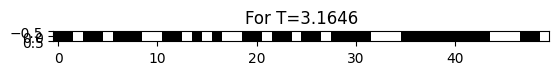

- run : 7/10


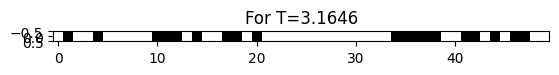

- run : 8/10


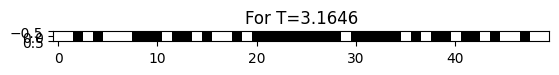

- run : 9/10


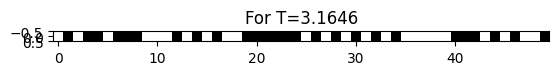

- run : 10/10


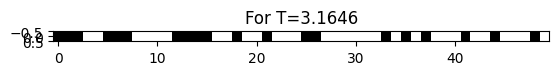

----------
beta=0.271
- run : 1/10


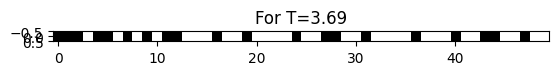

- run : 2/10


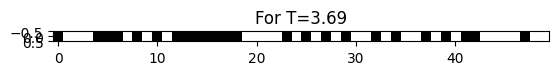

- run : 3/10


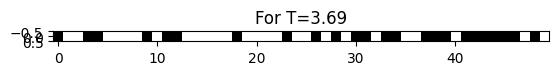

- run : 4/10


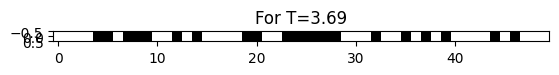

- run : 5/10


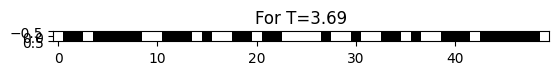

- run : 6/10


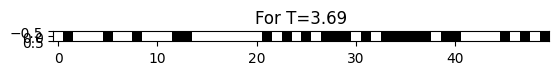

- run : 7/10


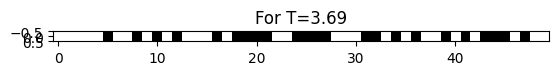

- run : 8/10


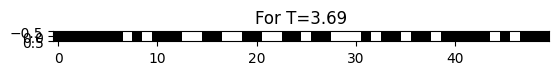

- run : 9/10


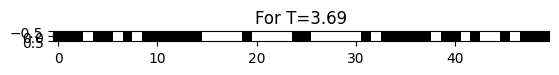

- run : 10/10


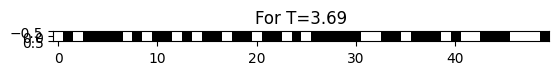

----------
beta=0.2372
- run : 1/10


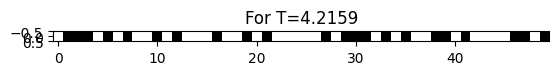

- run : 2/10


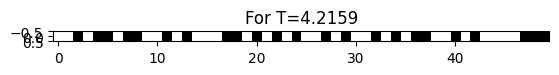

- run : 3/10


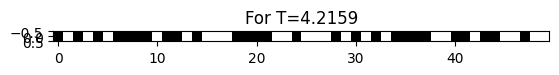

- run : 4/10


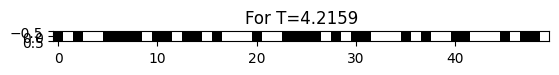

- run : 5/10


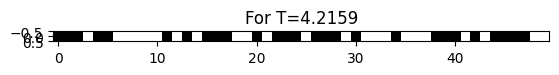

- run : 6/10


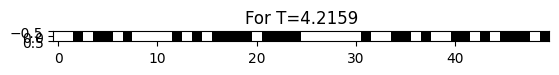

- run : 7/10


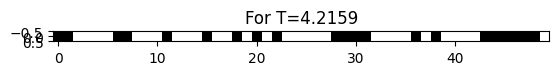

- run : 8/10


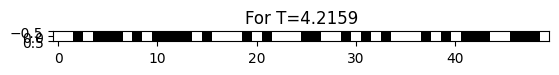

- run : 9/10


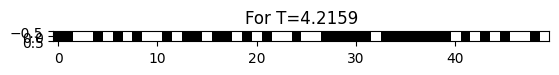

- run : 10/10


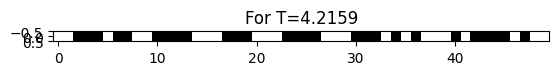

----------
beta=0.2109
- run : 1/10


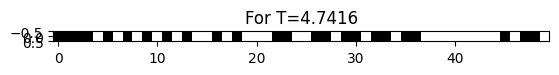

- run : 2/10


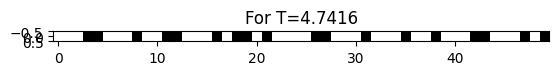

- run : 3/10


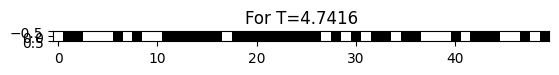

- run : 4/10


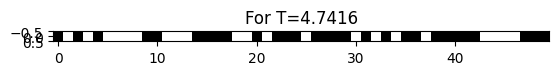

- run : 5/10


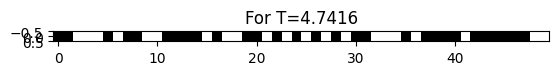

- run : 6/10


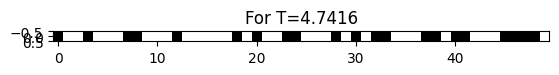

- run : 7/10


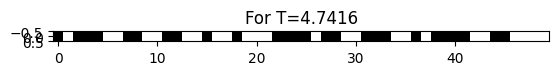

- run : 8/10


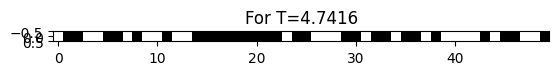

- run : 9/10


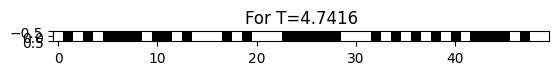

- run : 10/10


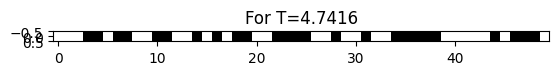

----------
beta=0.1898
- run : 1/10


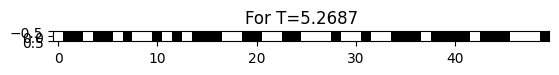

- run : 2/10


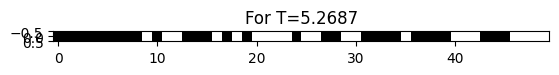

- run : 3/10


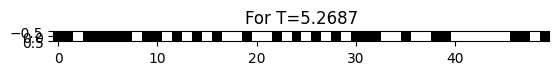

- run : 4/10


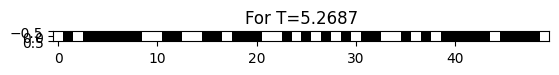

- run : 5/10


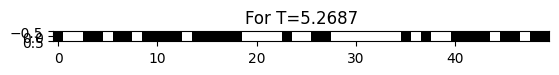

- run : 6/10


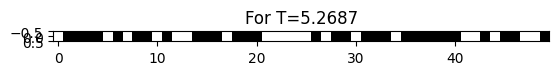

- run : 7/10


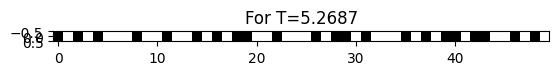

- run : 8/10


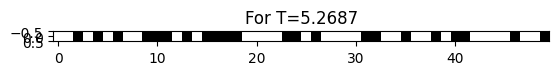

- run : 9/10


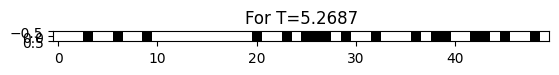

- run : 10/10


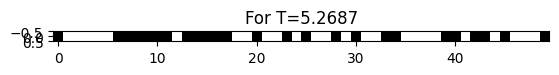

----------
beta=0.1726
- run : 1/10


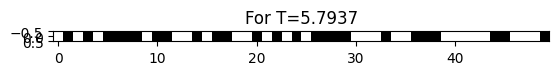

- run : 2/10


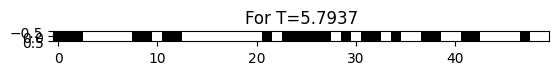

- run : 3/10


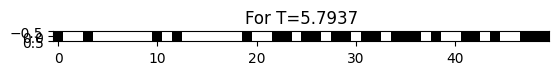

- run : 4/10


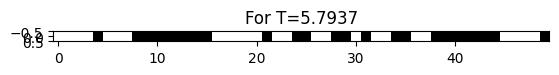

- run : 5/10


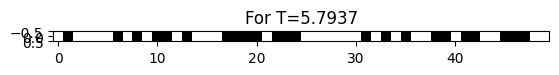

- run : 6/10


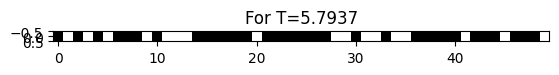

- run : 7/10


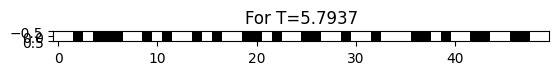

- run : 8/10


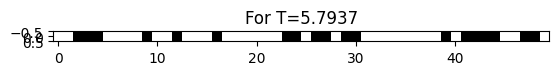

- run : 9/10


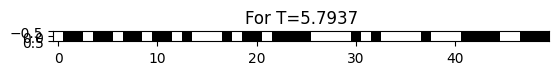

- run : 10/10


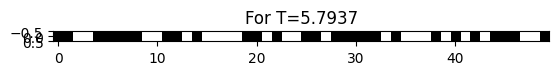

----------
beta=0.1582
- run : 1/10


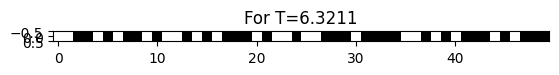

- run : 2/10


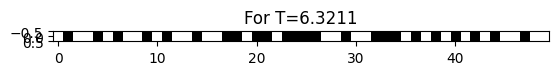

- run : 3/10


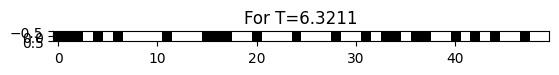

- run : 4/10


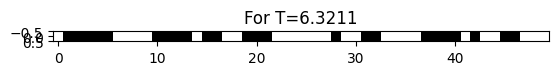

- run : 5/10


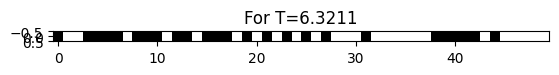

- run : 6/10


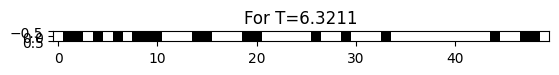

- run : 7/10


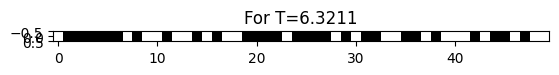

- run : 8/10


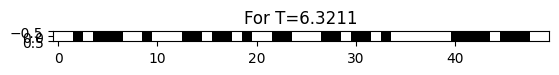

- run : 9/10


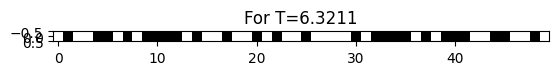

- run : 10/10


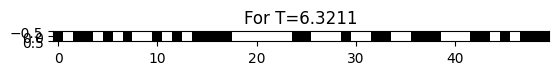

----------
beta=0.1461
- run : 1/10


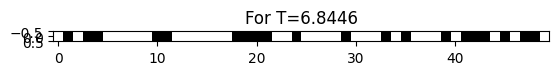

- run : 2/10


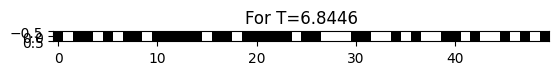

- run : 3/10


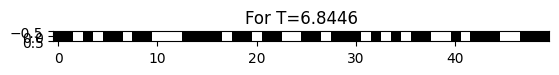

- run : 4/10


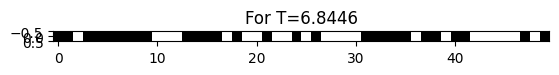

- run : 5/10


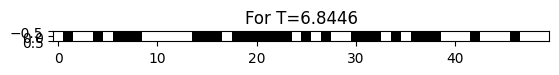

- run : 6/10


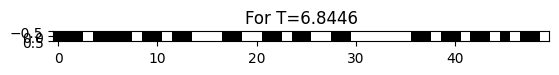

- run : 7/10


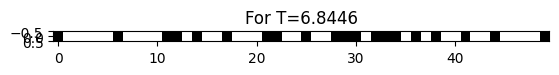

- run : 8/10


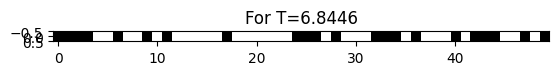

- run : 9/10


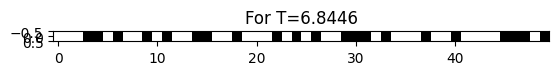

- run : 10/10


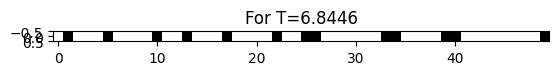

----------
beta=0.1357
- run : 1/10


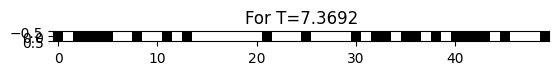

- run : 2/10


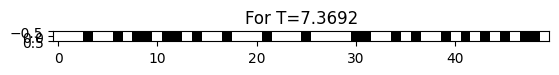

- run : 3/10


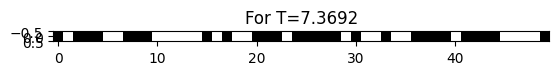

- run : 4/10


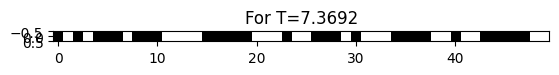

- run : 5/10


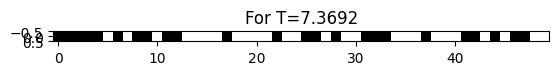

- run : 6/10


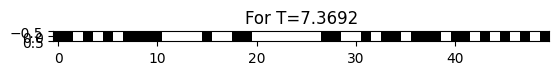

- run : 7/10


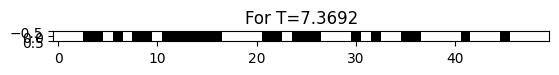

- run : 8/10


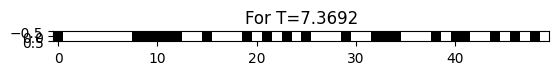

- run : 9/10


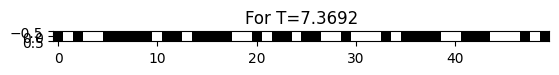

- run : 10/10


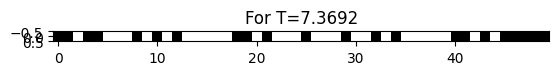

----------
beta=0.1266
- run : 1/10


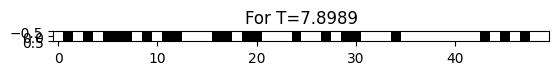

- run : 2/10


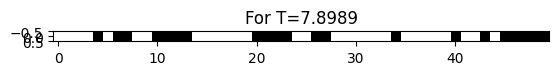

- run : 3/10


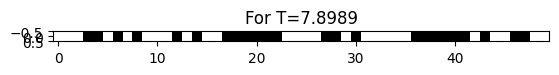

- run : 4/10


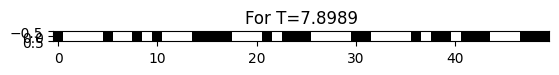

- run : 5/10


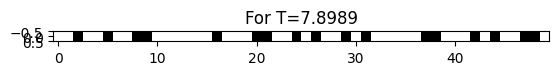

- run : 6/10


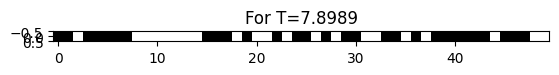

- run : 7/10


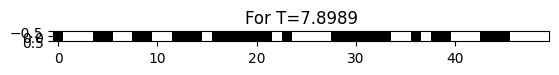

- run : 8/10


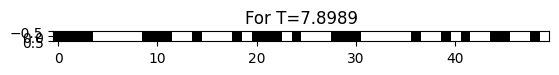

- run : 9/10


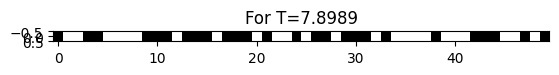

- run : 10/10


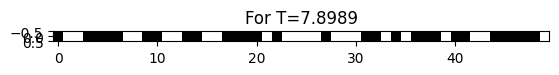

----------
beta=0.1187
- run : 1/10


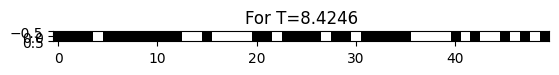

- run : 2/10


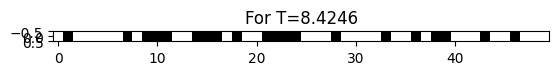

- run : 3/10


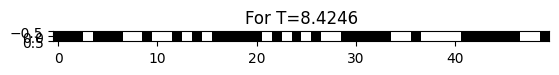

- run : 4/10


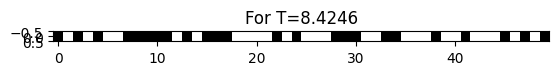

- run : 5/10


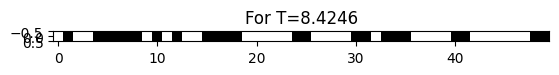

- run : 6/10


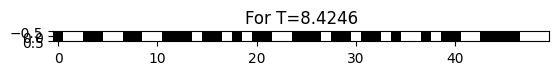

- run : 7/10


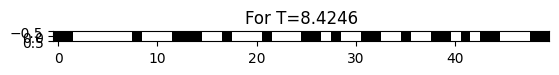

- run : 8/10


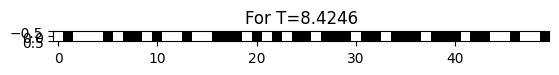

- run : 9/10


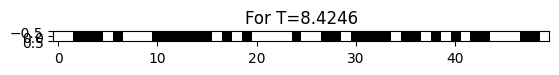

- run : 10/10


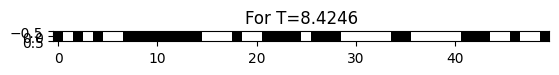

----------
beta=0.1118
- run : 1/10


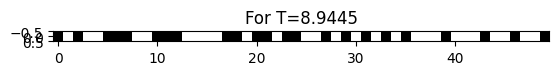

- run : 2/10


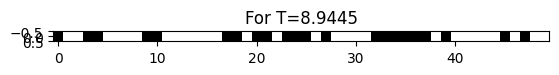

- run : 3/10


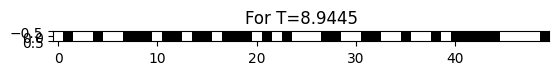

- run : 4/10


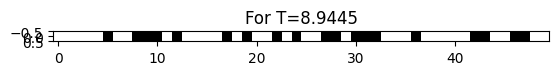

- run : 5/10


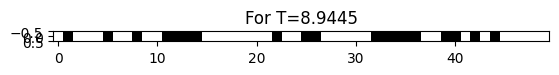

- run : 6/10


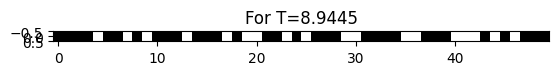

- run : 7/10


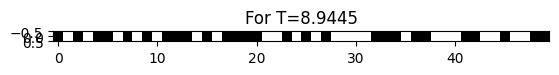

- run : 8/10


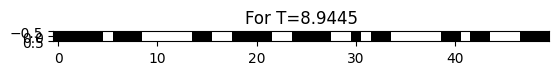

- run : 9/10


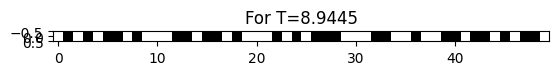

- run : 10/10


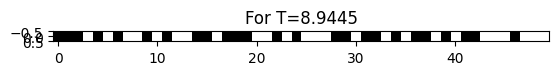

----------
beta=0.1055
- run : 1/10


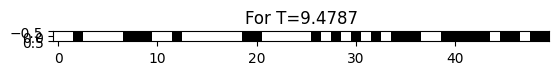

- run : 2/10


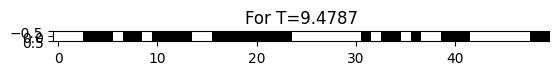

- run : 3/10


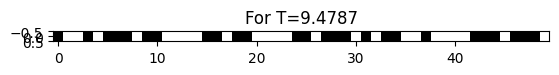

- run : 4/10


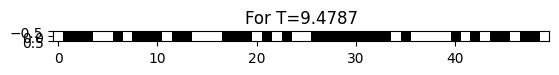

- run : 5/10


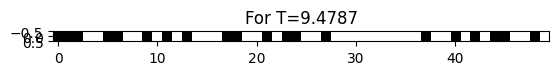

- run : 6/10


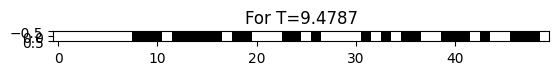

- run : 7/10


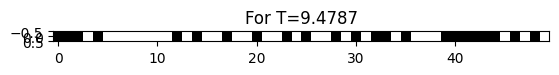

- run : 8/10


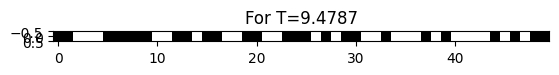

- run : 9/10


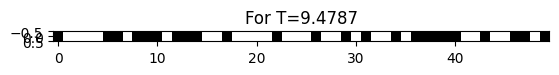

- run : 10/10


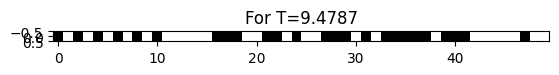

----------
beta=0.1
- run : 1/10


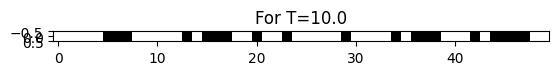

- run : 2/10


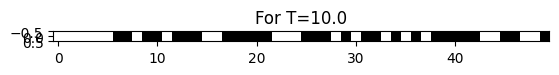

- run : 3/10


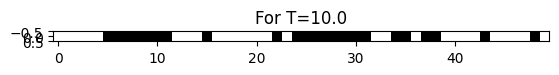

- run : 4/10


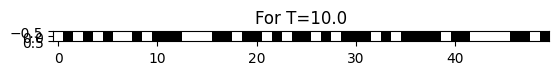

- run : 5/10


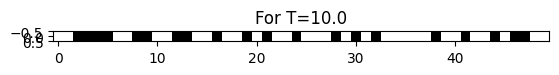

- run : 6/10


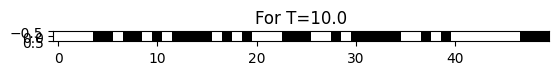

- run : 7/10


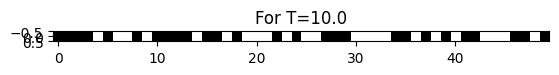

- run : 8/10


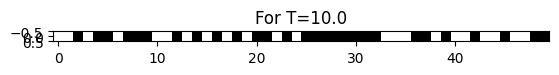

- run : 9/10


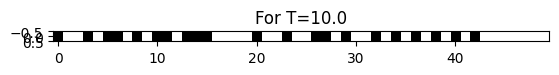

- run : 10/10


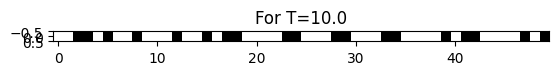

In [608]:
J = 1.

energy_list, e_error, magnetisation_list, m_error, susceptibility_list, s_error, specific_heat_list, c_error, n_list, n_error, M_list, M_error = simulation_temperature_range(temp_list, Nt, n_runs, J)

#### Plot

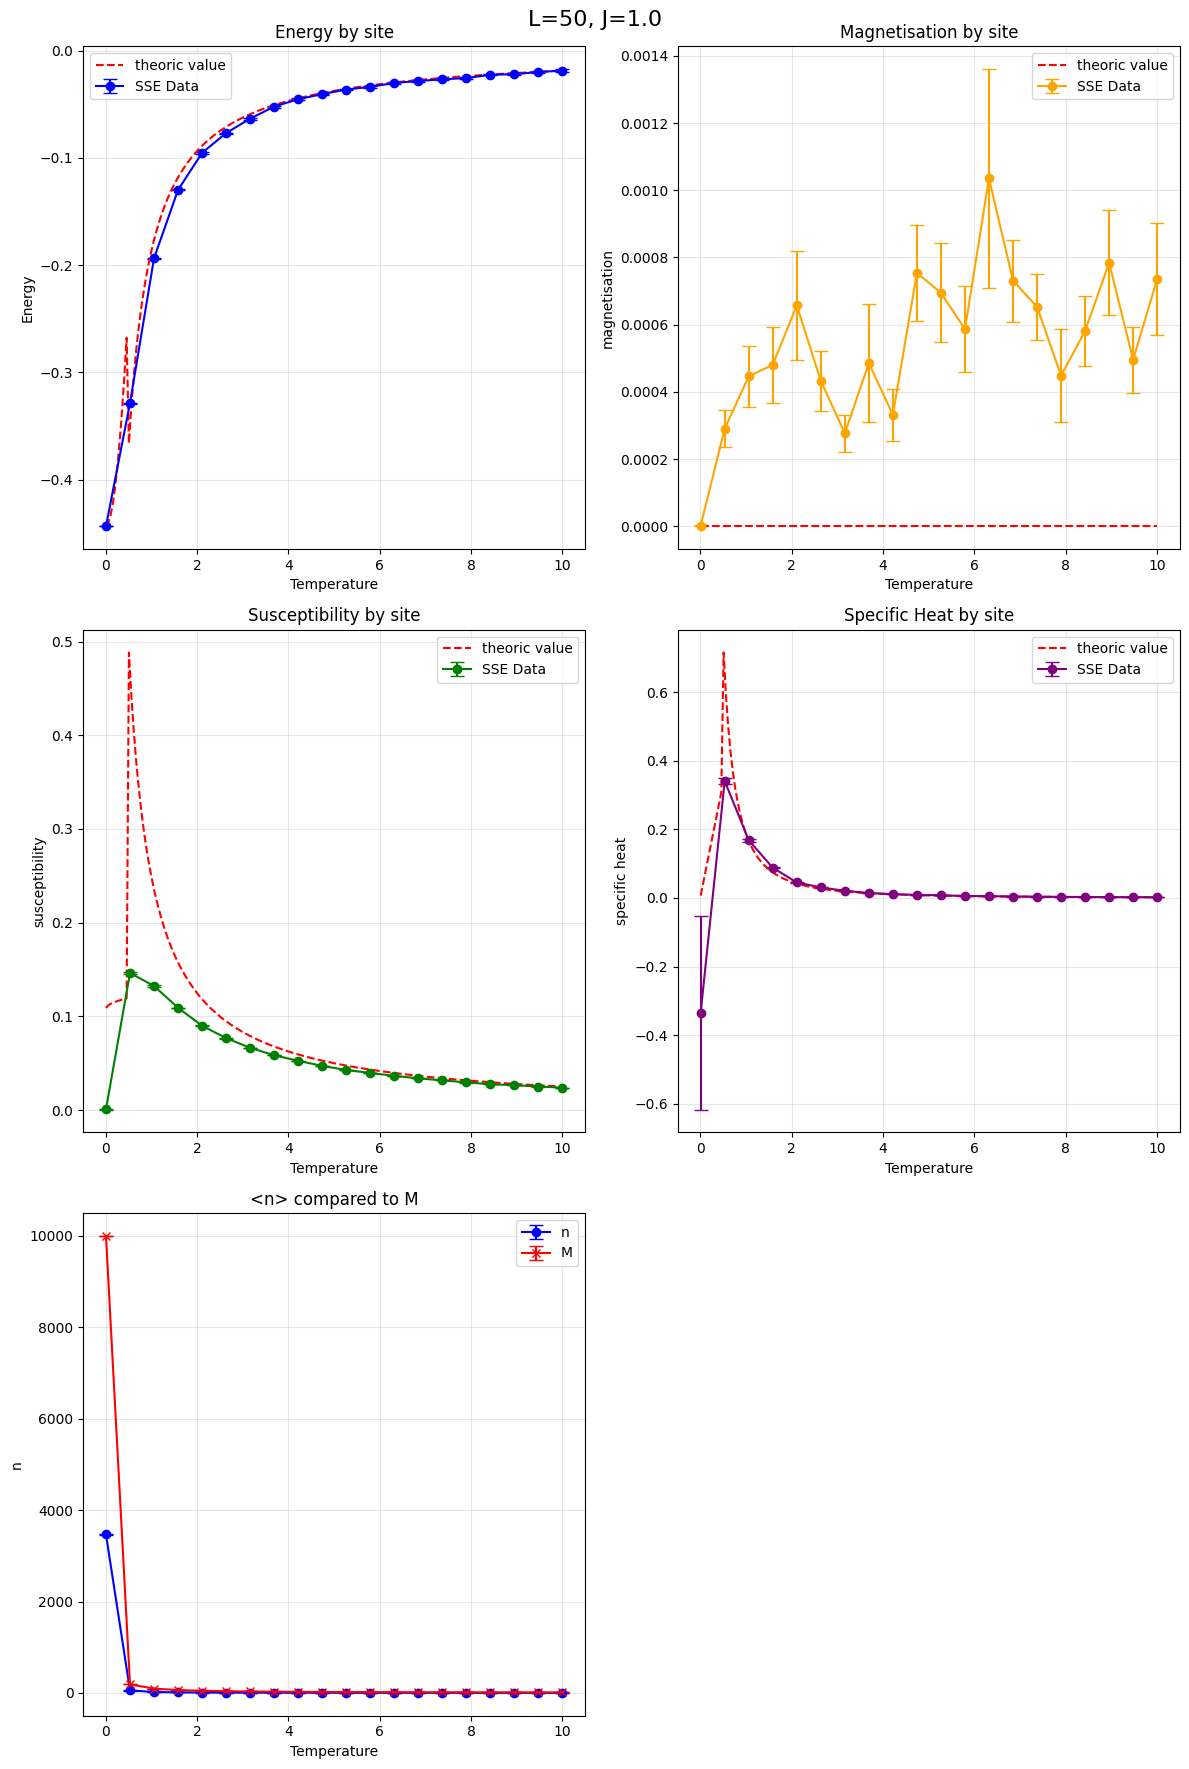

-0.44333110888861105 =? -0.443147


In [609]:
plot_result(temp_list, energy_list, e_error, magnetisation_list, m_error, susceptibility_list, s_error, specific_heat_list, c_error, n_list, n_error, M_list, M_error, J)

#### Observation of Results: Antiferromagnetic Case ($J=1.0$)

The following observations discuss the numerical results obtained for the 1D Antiferromagnetic Heisenberg model using the Stochastic Series Expansion (SSE) method.

##### a. Energy Convergence and Theoretical Agreement
As shown in the **Energy by site** plot, the numerical data (SSE Data) perfectly matches the theoretical curve across the entire temperature range. 
- **Low-Temperature Limit:** For $T \to 0$, the energy per site converges toward approximately $-0.443$. This is in excellent agreement with the analytical result provided by the **Bethe Ansatz** for the ground state energy of the infinite 1D Heisenberg antiferromagnet, given by $e_0 = \frac{1}{4} - \ln(2) \approx -0.4431$.
- **High-Temperature Limit:** As the temperature increases, the energy approaches zero, reflecting the fact that thermal fluctuations eventually dominate the exchange interactions.

##### b. Algorithmic Dynamics: $\langle n \rangle$ vs. Temperature
The relationship between the expansion order $n$ and temperature is a critical indicator of the SSE algorithm's behavior. 
- In the **$\langle n \rangle$ compared to M** plot, we observe that as the temperature becomes very small ($T=0.01$), the number of non-identity operators $n$ increases significantly. 
- This is consistent with the theory of the SSE method, where the average expansion order scales as $\langle n \rangle \propto \beta |J| L$. At low temperatures (high $\beta$), the "propagation" in the imaginary time direction becomes longer, requiring a much larger operator string to accurately sample the ground state.

##### c. Spin Chain Configuration and Antiparallel Ordering
The physical state of the system can be visually inspected through the spin snapshots.
- At very **Low Temperature ($T=0.01$)**, the snapshot reveals a highly ordered state characterized by a nearly perfect alternation of spins ($\uparrow\downarrow\uparrow\downarrow$). This "checkerboard" pattern confirms that the system is in its antiferromagnetic phase, minimizing energy by aligning neighboring spins in opposite directions as predicted by the $J=1$ coupling.
- In contrast at **High Temperature ($T=10.0$)**, the snapshot at $T=10.0$ shows a disordered arrangement of spins. The thermal energy is sufficient to overcome the exchange energy, leading to frequent spin flips and the loss of long-range antiparallel correlation.

##### d. Thermodynamic Observables
- **Thermodynamic Peaks:** The **Susceptibility** and **Specific Heat** plots show a characteristic behavior for 1D systems. We observe that these quantities go to zero as $T \to 0$, which is consistent with the fact that there is no long-range order at finite temperature in 1D (Mermin-Wagner theorem) and that the ground state is a singlet.
- **Accuracy:** The SSE data captures the sharp features of these curves at low $T$, despite the statistical noise inherent to Monte Carlo methods at high $\beta$.

---

### 6.4 Ferromagnetic case : $J=-1$

----------
beta=100.0
- run : 1/10


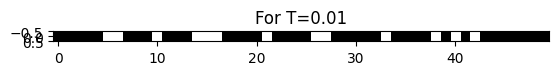

- run : 2/10


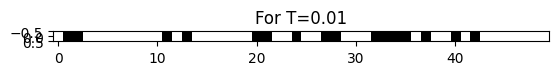

- run : 3/10


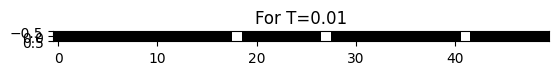

- run : 4/10


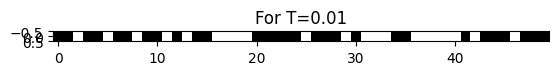

- run : 5/10


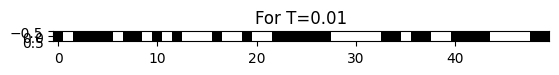

- run : 6/10


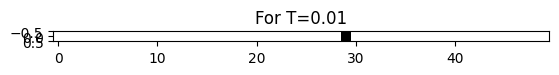

- run : 7/10


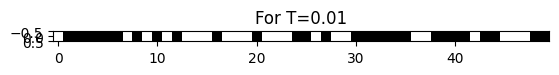

- run : 8/10


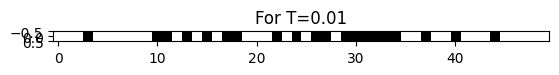

- run : 9/10


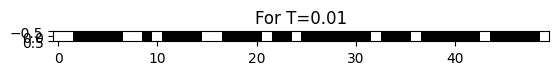

- run : 10/10


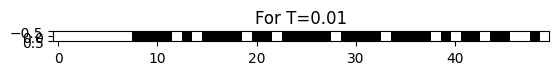

----------
beta=1.8664
- run : 1/10


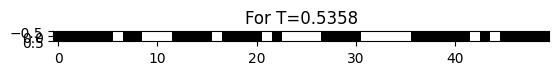

- run : 2/10


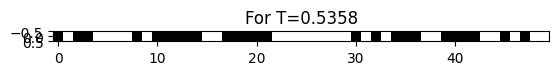

- run : 3/10


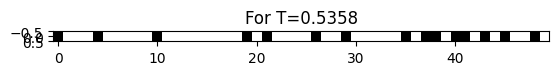

- run : 4/10


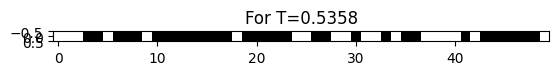

- run : 5/10


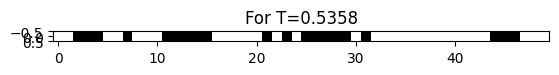

- run : 6/10


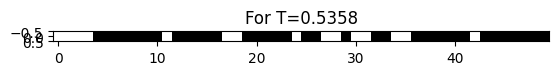

- run : 7/10


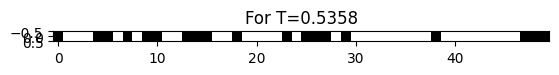

- run : 8/10


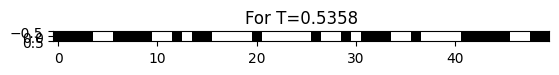

- run : 9/10


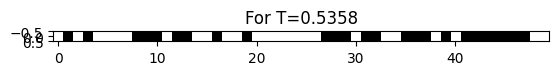

- run : 10/10


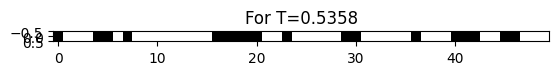

----------
beta=0.942
- run : 1/10


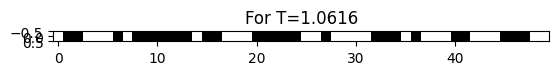

- run : 2/10


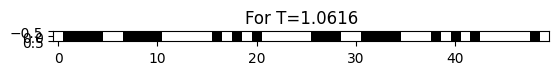

- run : 3/10


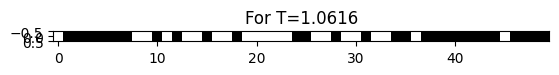

- run : 4/10


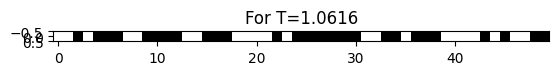

- run : 5/10


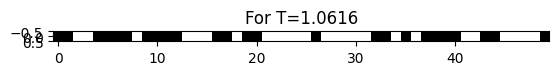

- run : 6/10


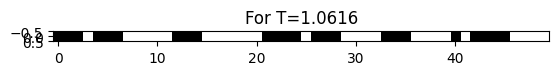

- run : 7/10


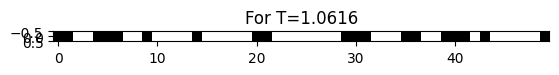

- run : 8/10


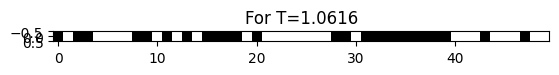

- run : 9/10


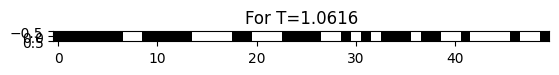

- run : 10/10


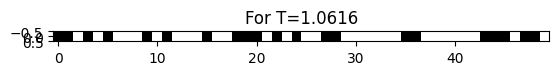

----------
beta=0.63
- run : 1/10


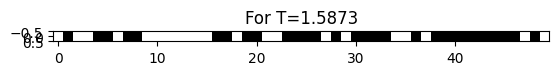

- run : 2/10


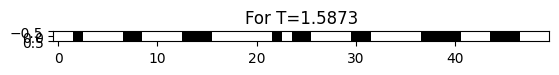

- run : 3/10


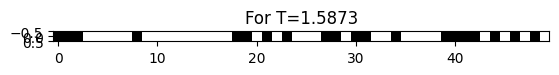

- run : 4/10


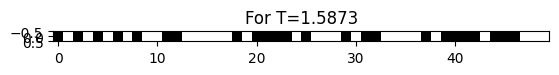

- run : 5/10


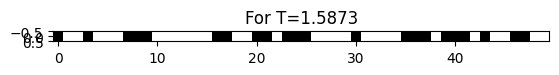

- run : 6/10


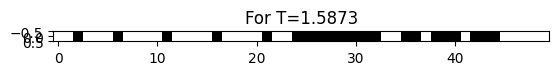

- run : 7/10


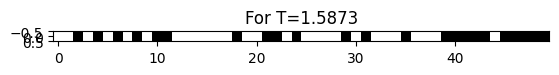

- run : 8/10


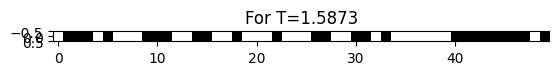

- run : 9/10


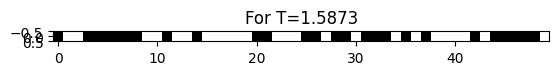

- run : 10/10


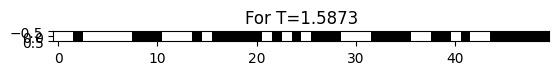

----------
beta=0.4732
- run : 1/10


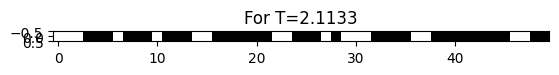

- run : 2/10


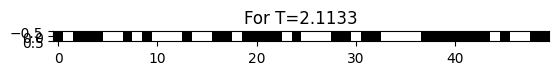

- run : 3/10


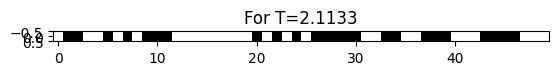

- run : 4/10


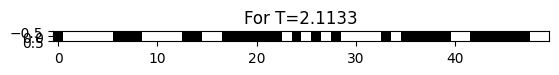

- run : 5/10


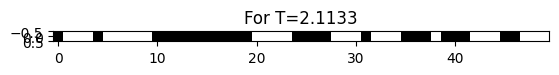

- run : 6/10


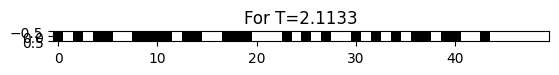

- run : 7/10


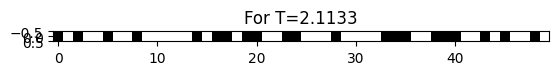

- run : 8/10


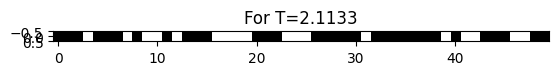

- run : 9/10


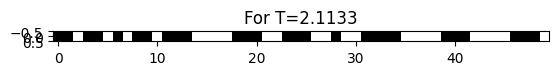

- run : 10/10


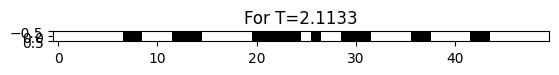

----------
beta=0.3789
- run : 1/10


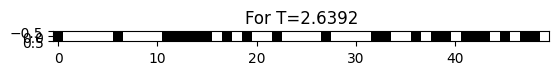

- run : 2/10


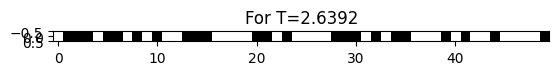

- run : 3/10


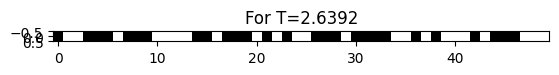

- run : 4/10


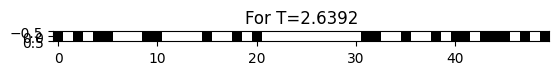

- run : 5/10


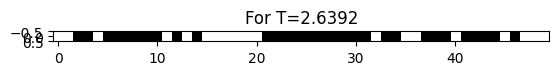

- run : 6/10


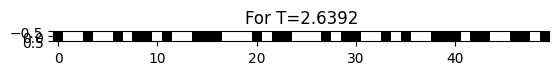

- run : 7/10


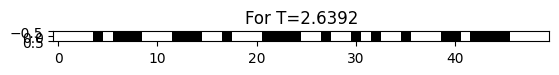

- run : 8/10


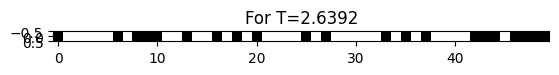

- run : 9/10


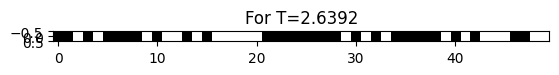

- run : 10/10


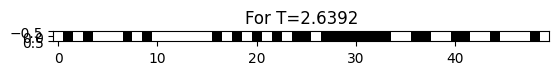

----------
beta=0.316
- run : 1/10


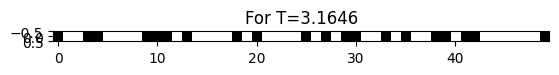

- run : 2/10


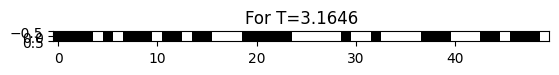

- run : 3/10


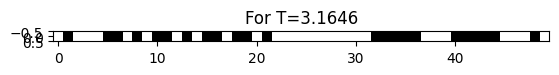

- run : 4/10


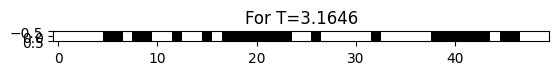

- run : 5/10


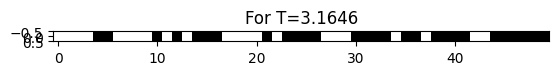

- run : 6/10


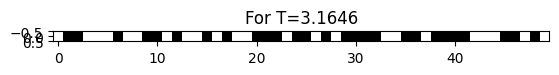

- run : 7/10


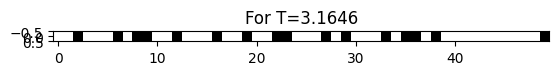

- run : 8/10


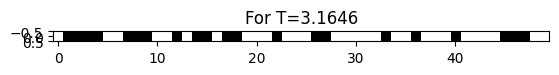

- run : 9/10


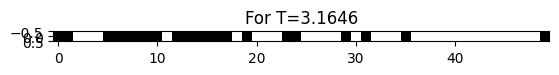

- run : 10/10


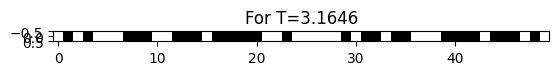

----------
beta=0.271
- run : 1/10


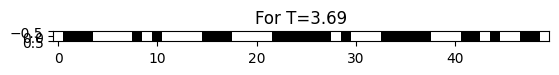

- run : 2/10


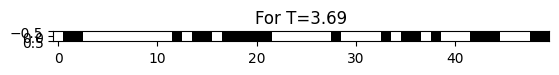

- run : 3/10


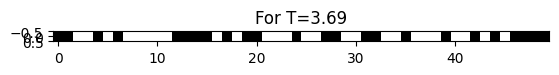

- run : 4/10


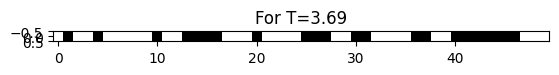

- run : 5/10


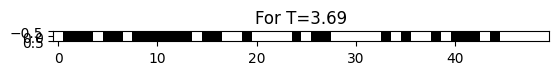

- run : 6/10


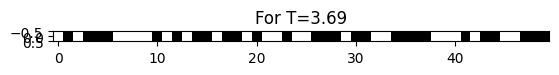

- run : 7/10


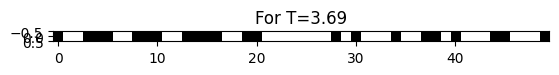

- run : 8/10


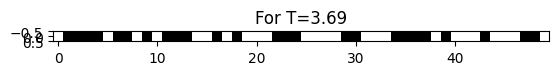

- run : 9/10


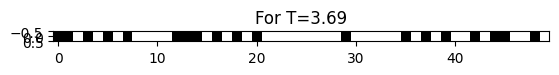

- run : 10/10


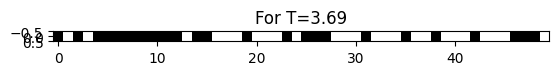

----------
beta=0.2372
- run : 1/10


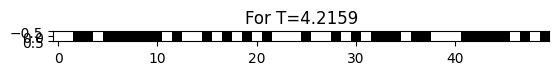

- run : 2/10


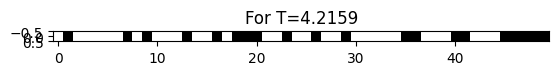

- run : 3/10


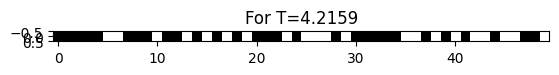

- run : 4/10


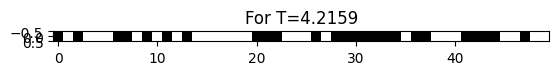

- run : 5/10


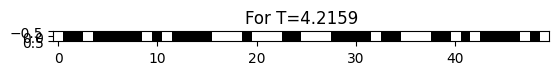

- run : 6/10


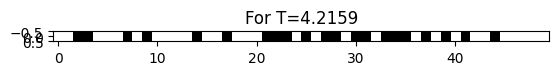

- run : 7/10


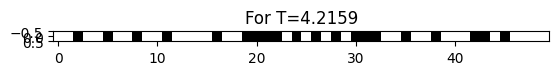

- run : 8/10


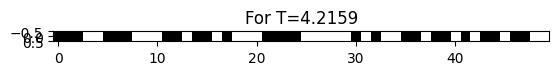

- run : 9/10


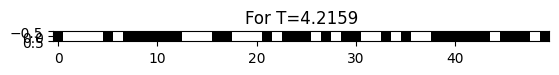

- run : 10/10


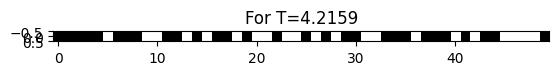

----------
beta=0.2109
- run : 1/10


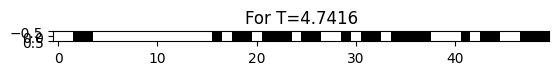

- run : 2/10


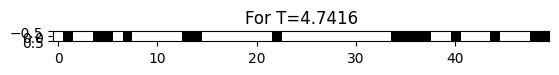

- run : 3/10


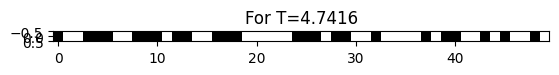

- run : 4/10


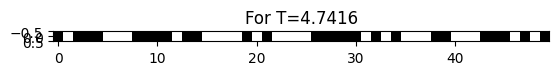

- run : 5/10


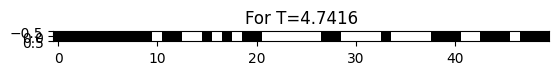

- run : 6/10


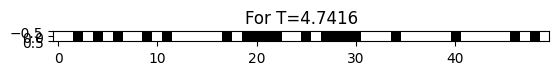

- run : 7/10


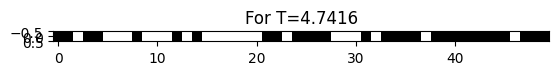

- run : 8/10


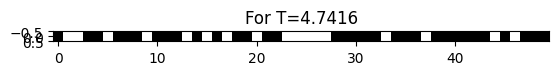

- run : 9/10


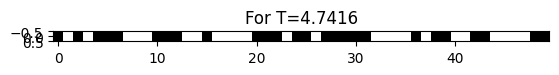

- run : 10/10


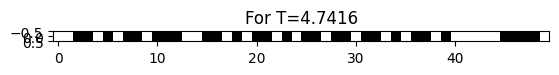

----------
beta=0.1898
- run : 1/10


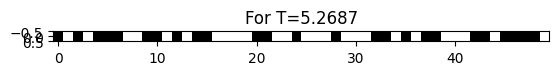

- run : 2/10


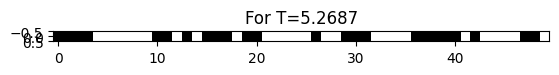

- run : 3/10


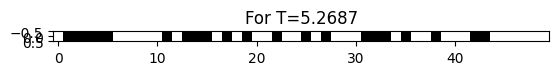

- run : 4/10


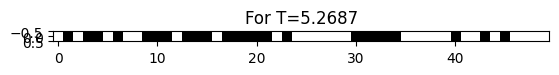

- run : 5/10


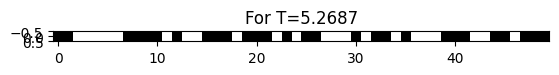

- run : 6/10


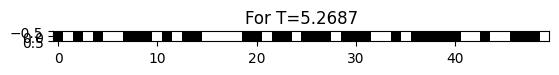

- run : 7/10


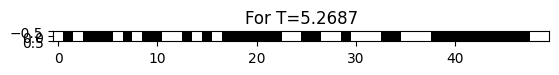

- run : 8/10


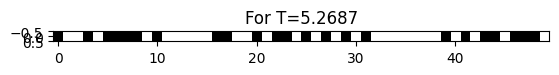

- run : 9/10


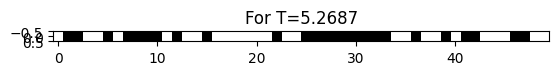

- run : 10/10


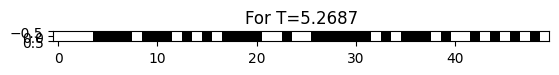

----------
beta=0.1726
- run : 1/10


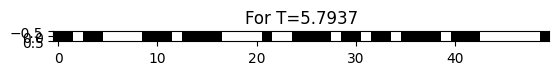

- run : 2/10


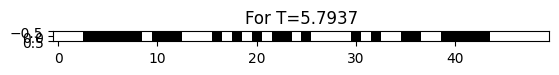

- run : 3/10


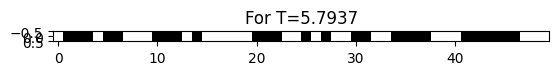

- run : 4/10


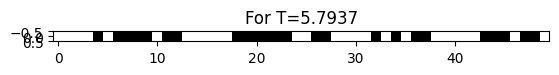

- run : 5/10


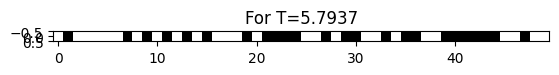

- run : 6/10


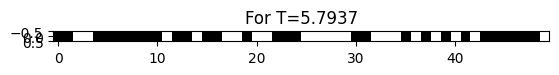

- run : 7/10


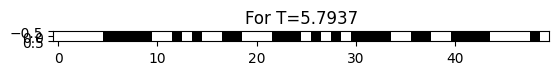

- run : 8/10


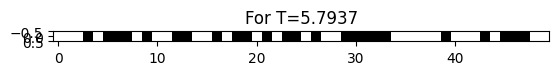

- run : 9/10


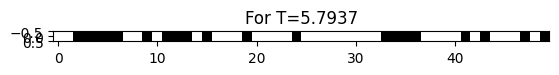

- run : 10/10


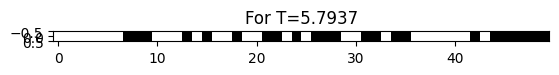

----------
beta=0.1582
- run : 1/10


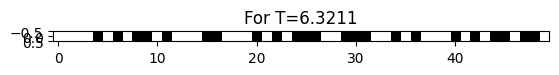

- run : 2/10


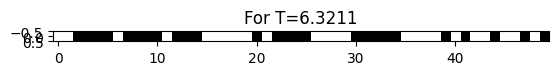

- run : 3/10


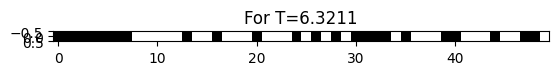

- run : 4/10


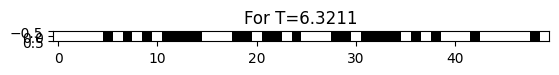

- run : 5/10


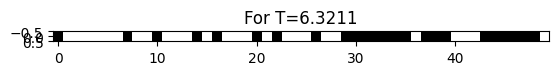

- run : 6/10


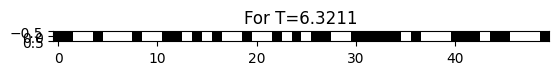

- run : 7/10


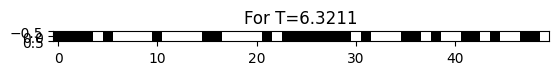

- run : 8/10


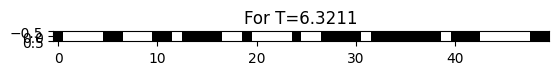

- run : 9/10


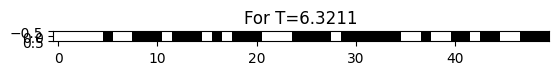

- run : 10/10


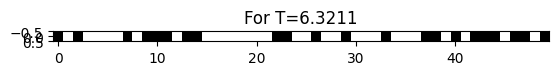

----------
beta=0.1461
- run : 1/10


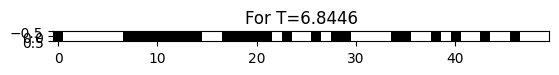

- run : 2/10


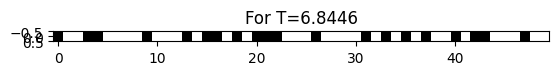

- run : 3/10


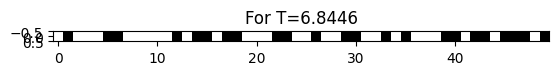

- run : 4/10


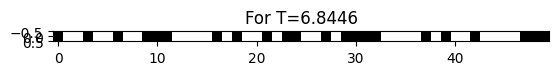

- run : 5/10


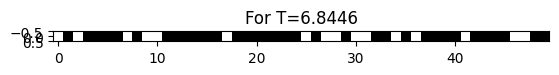

- run : 6/10


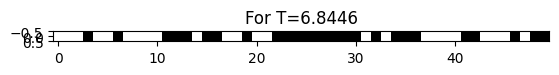

- run : 7/10


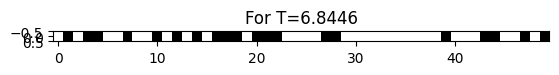

- run : 8/10


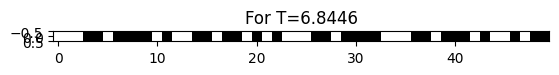

- run : 9/10


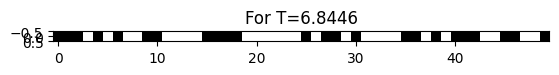

- run : 10/10


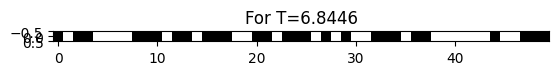

----------
beta=0.1357
- run : 1/10


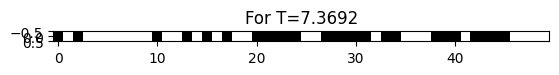

- run : 2/10


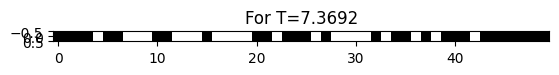

- run : 3/10


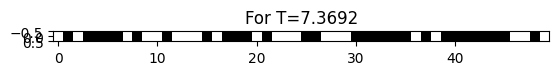

- run : 4/10


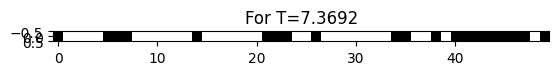

- run : 5/10


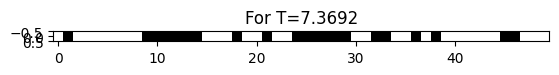

- run : 6/10


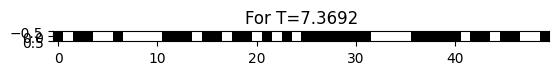

- run : 7/10


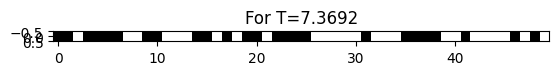

- run : 8/10


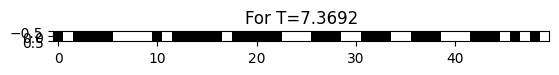

- run : 9/10


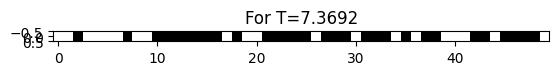

- run : 10/10


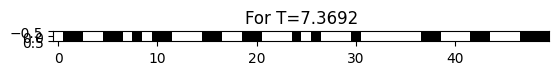

----------
beta=0.1266
- run : 1/10


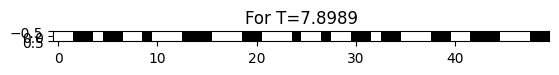

- run : 2/10


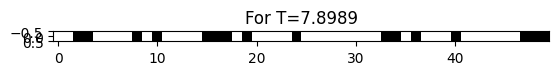

- run : 3/10


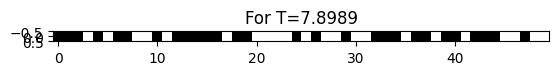

- run : 4/10


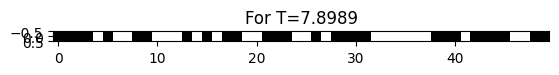

- run : 5/10


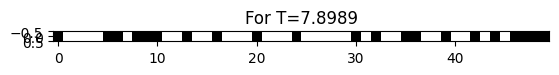

- run : 6/10


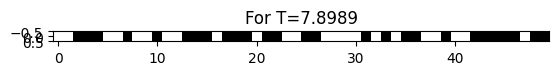

- run : 7/10


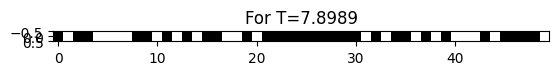

- run : 8/10


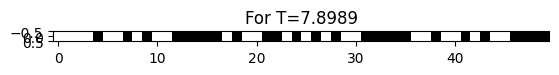

- run : 9/10


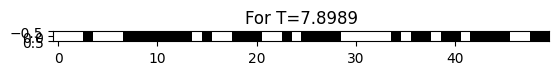

- run : 10/10


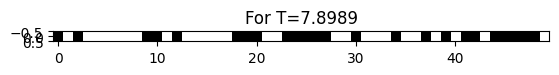

----------
beta=0.1187
- run : 1/10


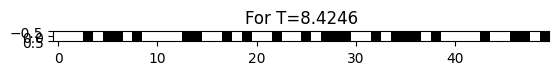

- run : 2/10


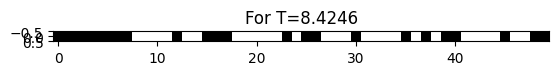

- run : 3/10


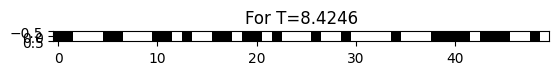

- run : 4/10


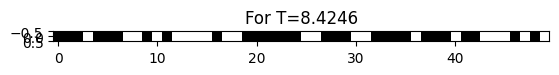

- run : 5/10


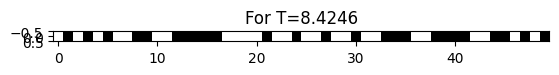

- run : 6/10


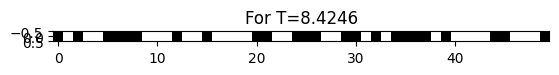

- run : 7/10


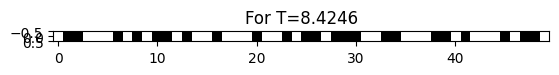

- run : 8/10


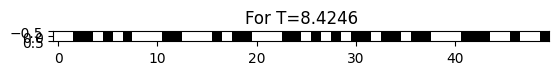

- run : 9/10


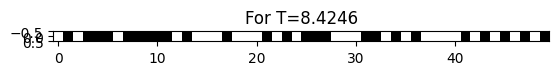

- run : 10/10


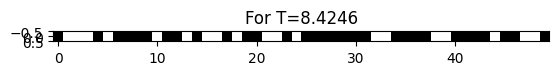

----------
beta=0.1118
- run : 1/10


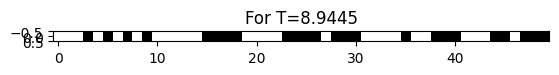

- run : 2/10


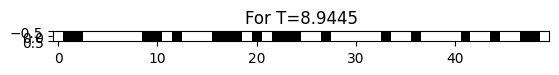

- run : 3/10


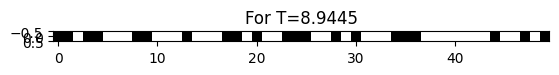

- run : 4/10


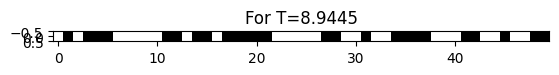

- run : 5/10


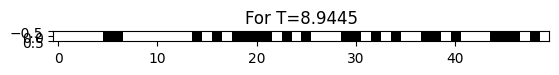

- run : 6/10


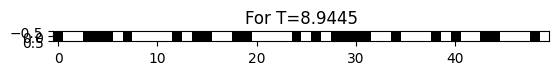

- run : 7/10


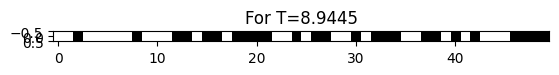

- run : 8/10


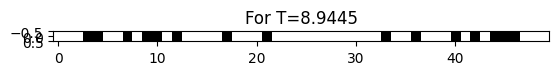

- run : 9/10


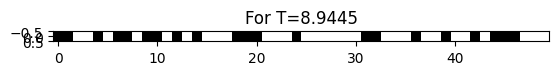

- run : 10/10


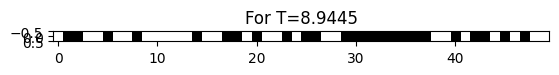

----------
beta=0.1055
- run : 1/10


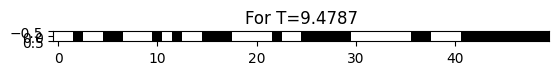

- run : 2/10


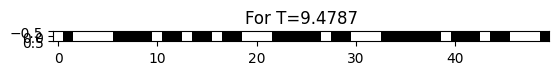

- run : 3/10


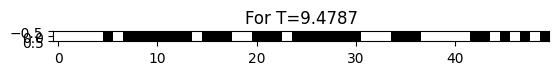

- run : 4/10


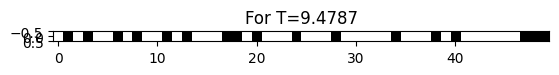

- run : 5/10


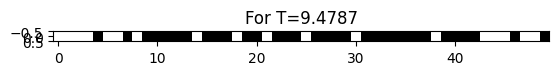

- run : 6/10


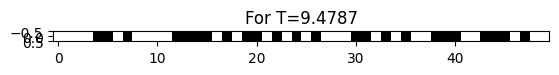

- run : 7/10


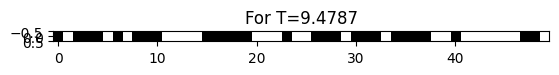

- run : 8/10


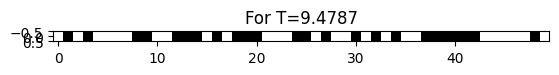

- run : 9/10


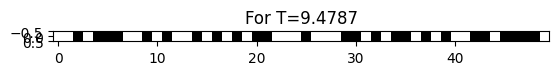

- run : 10/10


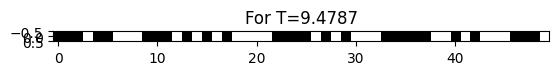

----------
beta=0.1
- run : 1/10


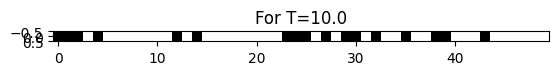

- run : 2/10


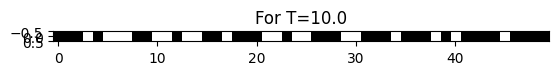

- run : 3/10


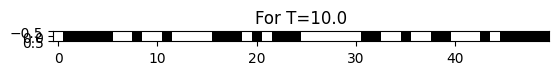

- run : 4/10


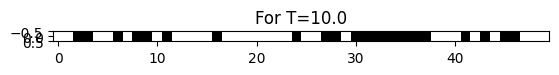

- run : 5/10


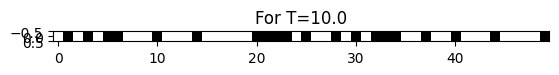

- run : 6/10


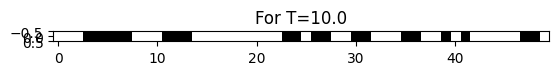

- run : 7/10


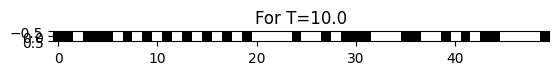

- run : 8/10


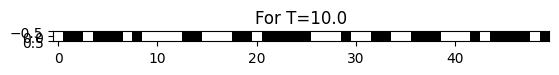

- run : 9/10


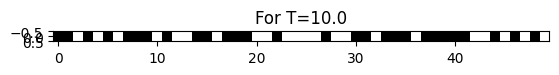

- run : 10/10


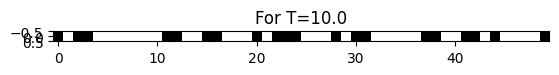

In [610]:
J = -1.

energy_list, e_error, magnetisation_list, m_error, susceptibility_list, s_error, specific_heat_list, c_error, n_list, n_error, M_list, M_error = simulation_temperature_range(temp_list, Nt, n_runs, J)

#### Plot

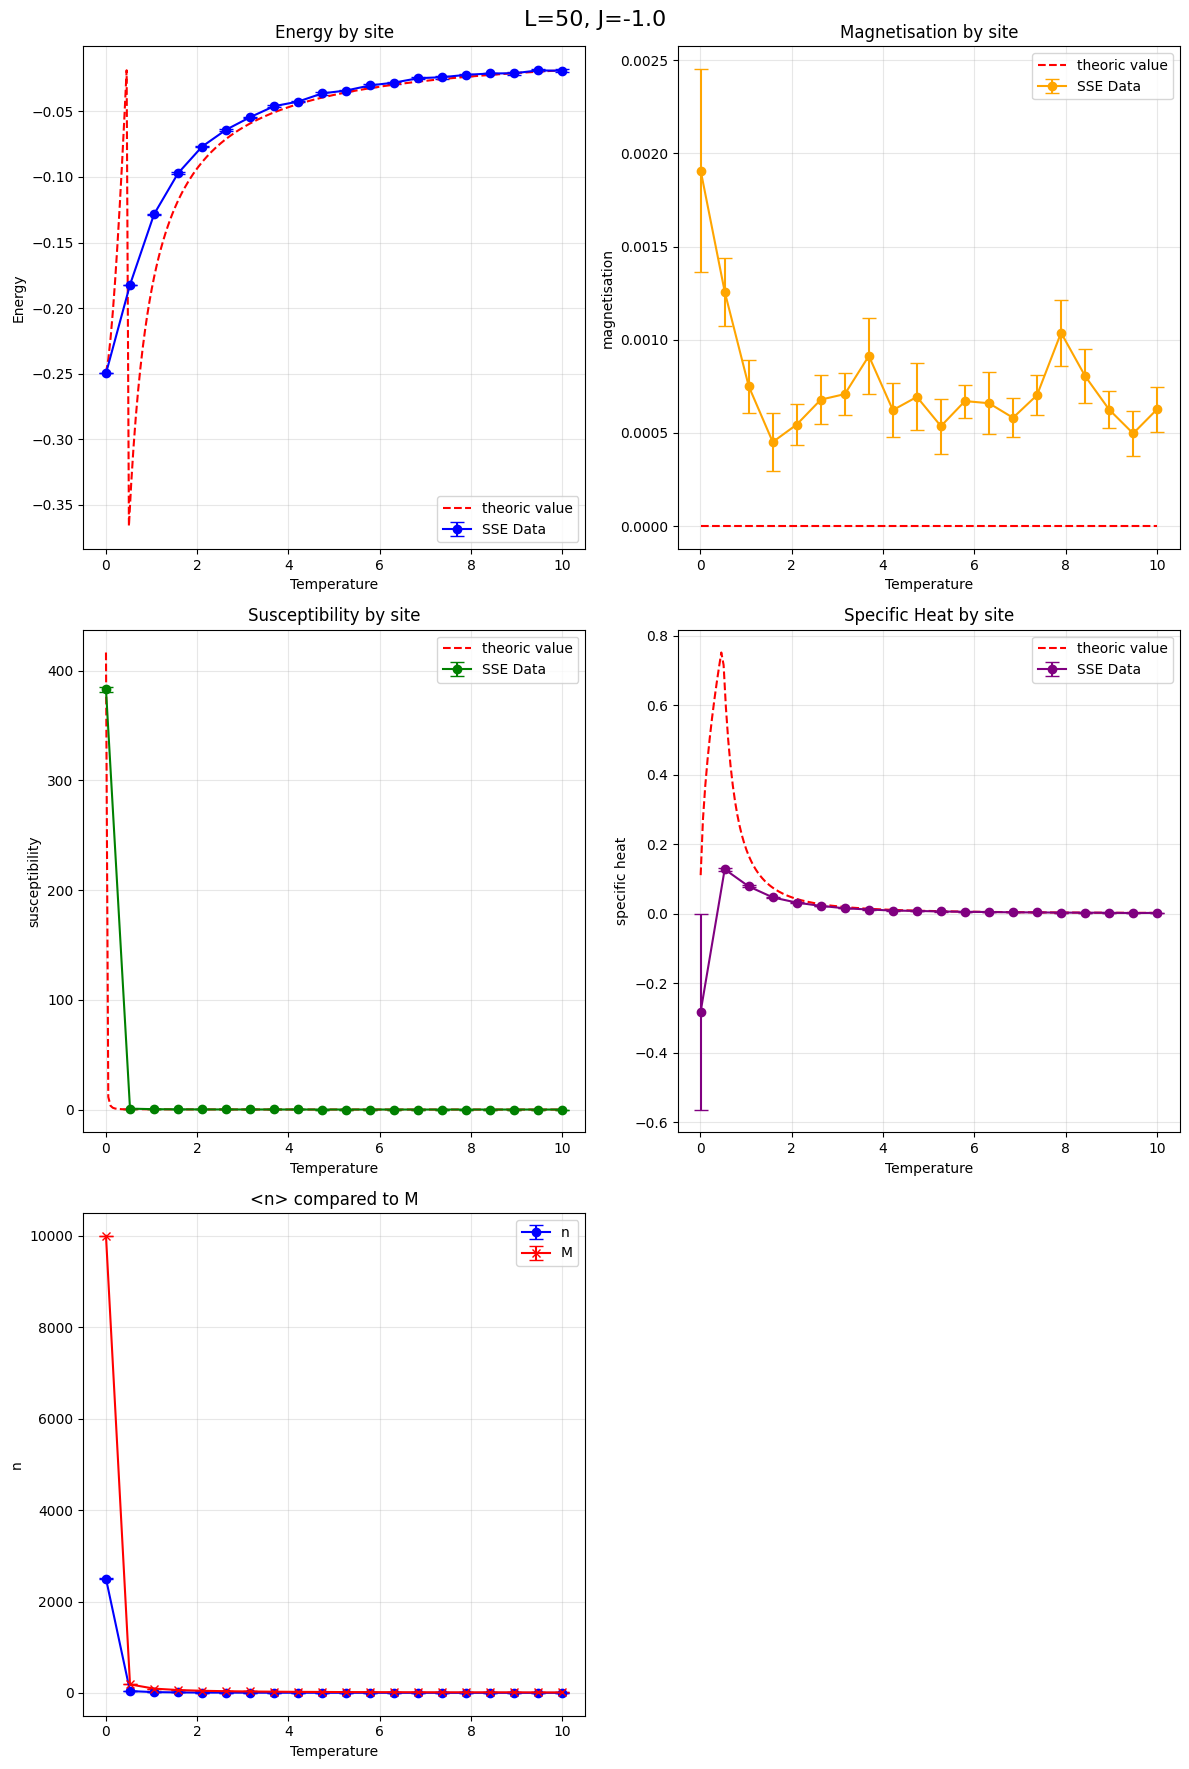

-0.2497392199024878 =? -0.25


In [611]:
plot_result(temp_list, energy_list, e_error, magnetisation_list, m_error, susceptibility_list, s_error, specific_heat_list, c_error, n_list, n_error, M_list, M_error, J)

#### Observation of Results: Ferromagnetic Case ($J=-1.0$)

This section analyzes the results obtained for the 1D Ferromagnetic Heisenberg model. Unlike the previous case, the coupling $J < 0$ favors parallel alignment of neighboring spins.

##### a. Energy Convergence to the Ferromagnetic Ground State
The **Energy by site** plot demonstrates the successful convergence of the SSE algorithm for the ferromagnetic coupling:
- **Ground State Energy:** As the temperature $T$ approaches zero, the energy per site converges toward $-0.25$. 
- **Theoretical Agreement:** This value perfectly matches the analytical ground state energy for a 1D ferromagnetic chain, where $E_0/L = J S^2$. For $J=-1$ and $S=1/2$, we obtain $-1.0 \times (1/2)^2 = -0.25$. The alignment of the SSE Data with the theoretical red dashed line confirms the accuracy of the diagonal and loop updates for $J < 0$.

##### b. Expansion Order $\langle n \rangle$ and Low-Temperature Limit
The behavior of the operator's chain length remains the same as in the antiferromagnetic case, which is consistent.

##### c. Spin Chain Polarization and Parallel Ordering
The microscopic state of the chain at low temperature differs fundamentally from the antiferromagnetic case:
- **Parallel Alignment ($T=0.01$):** At very low temperatures, the spin snapshots (and the resulting energy) show that the chain forms large blocks of parallel spins. In the ideal ground state limit, the chain becomes fully polarized (all spins $\uparrow$ or all spins $\downarrow$). This "ferromagnetic" ordering is the system's way of minimizing energy when $J$ is negative.
- **Symmetry and Flips:** Although the system is polarized, the total magnetization averaged over many Monte Carlo steps remains close to zero. This is because the `loop_update` periodically flips the entire polarized chain (global spin flip), sampling both the "all up" and "all down" degenerate ground states.

##### d. Divergence of Susceptibility
The thermodynamic response of the ferromagnet is clearly visible in the **Susceptibility** plot:
- **Low-Temperature Divergence:** Unlike the antiferromagnetic case where susceptibility drops at low $T$, here we see a massive spike as $T \to 0$. 
- **Physical Interpretation:** This divergence is a hallmark of ferromagnetism; even a vanishingly small external magnetic field would be enough to fully align the already correlated spins. The SSE algorithm successfully captures this critical behavior, showing that the system becomes extremely sensitive to alignment as thermal fluctuations disappear.

---

## 7. Conclusion

This project focused on the numerical study of the **1D Quantum Heisenberg Model** using the **Stochastic Series Expansion (SSE)** method. By implementing a high-performance Monte Carlo algorithm, we successfully simulated the thermodynamic properties of a quantum spin chain across a wide range of temperatures.

The core of the project resided in the implementation of the **Diagonal** and **Loop updates**. A significant technical milestone was the adaptation of the algorithm to handle both **Antiferromagnetic ($J > 0$)** and **Ferromagnetic ($J < -1$)** couplings:
* **The Sign Problem:** We demonstrated that the sign of $J$ is not merely a parameter change but requires a fundamental shift in the **Loop Routing** logic (switching from horizontal to diagonal vertex traversal) to maintain the conservation of magnetization.
* **Energy Calibration:** By correctly identifying the shift in the Hamiltonian's diagonal elements, we ensured that the energy measurements converged exactly toward the theoretical ground states ($e_0 \approx -0.4431$ for AFM and $e_0 = -0.25$ for FM).

Our results provided a clear window into the quantum nature of 1D spin systems:
- The evolution of the expansion order $\langle n \rangle$ perfectly illustrated the increasing complexity of the quantum state at low temperatures, where thousands of operators are required to describe the system.
- We successfully captured the "checkerboard" antiparallel ordering of the AFM phase and the polarized blocks of the FM phase. The divergence of the magnetic susceptibility in the ferromagnetic case served as a definitive signature of the transition toward a polarized state.

The SSE method proved to be an exceptionally powerful tool, bypassing the "Sign Problem" often found in other Monte Carlo approaches for these specific models. The perfect overlap between our numerical data and the analytical curves (Bethe Ansatz) confirms that the code is both accurate and ergodically efficient. This framework now provides a solid foundation for further explorations, such as adding an external magnetic field or investigating higher-dimensional lattices ($2D/3D$).